In [1]:
from Lab_Equipment.Config import config 

Current Directory: c:\Users\Experiment\Documents\RelBohmTraj\ExperimentStuff
This is a Windows system.
Deformable Mirror Software not installed. If needed to go and get software from USB website.


In [2]:
# Python Libs
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ctypes
import copy
from IPython.display import display, clear_output
import ipywidgets
# import multiprocessing
# from multiprocessing import shared_memory
import time
import scipy.io
import pickle
import TimeTagger
import os
import threading
import datetime

from scipy import io, integrate, linalg, signal
from scipy.io import savemat, loadmat
from scipy.fft import fft, fftfreq, fftshift,ifftshift, fft2,ifft2,rfft2,irfft2
# Defult Pploting properties 
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = [5,5]

#Moku Libs
import Lab_Equipment.MokuLab.MokuLabObject as mokulib




# #MPLC Libs
# import Lab_Equipment.MPLC.AlignmentRoutines as AlignRoutines
# import Lab_Equipment.AlignmentRoutines.AlignmentRoutines_PowerMeter as AlignPwrMetertLib

# timeTagger
import Lab_Equipment.TimeTagger.TimeTaggerLiveWindow as TimeTaggerLiveWindow
import Lab_Equipment.TimeTagger.TimeTaggerFunction as TimetaggerFunc
import Lab_Equipment.TimeTagger.TimeTaggerCustomMeasurementObj as TimeTaggerCustomObj



# Daniel's Python Libs NOTE there is a library in MyPyhtonLibs that causes the powermeter not to work 
# import  Lab_Equipment.MyPythonLibs.OpticalOperators as OpticOp
# import  Lab_Equipment.MyPythonLibs.ComplexPlotFunction as cmplxplt
# # import  Lab_Equipment.MyPythonLibs.GaussianBeamBasis as GaussBeams
# import  Lab_Equipment.MyPythonLibs.GeneralFunctions as GenFuncs
import  Lab_Equipment.MyPythonLibs.FWHMFunctions as FWHMFunc

# Piezo translation stage
import Lab_Equipment.ThorlabsKCube.ThorlabsPiezoStrainGauge as Piezolib

#Power Meter
import Lab_Equipment.PowerMeter.PowerMeter_Thorlabs_lib as PwrMeterLib

#Rotation Mount
import Lab_Equipment.ElliptecThorlabMounts.ElliptecRotationMountObject as RotMotLib


Current Directory: c:\Users\Experiment\Documents\RelBohmTraj\ExperimentStuff


In [3]:
%gui qt5
%load_ext autoreload

#Config File
%aimport Lab_Equipment.Config.config

# moku Lib
%aimport Lab_Equipment.MokuLab.MokuLabObject

#Alignment lib
# %aimport Lab_Equipment.AlignmentRoutines.AlignmentRoutines_PowerMeter

# timeTagger
# %aimport Lab_Equipment.TimeTagger.TimeTaggerInterface
%aimport Lab_Equipment.TimeTagger.TimeTaggerFunction
%aimport Lab_Equipment.TimeTagger.TimeTaggerCustomMeasurementObj




# power meter
%aimport Lab_Equipment.PowerMeter.PowerMeter_Thorlabs_lib

# Rotation Mounts
%aimport Lab_Equipment.ElliptecThorlabMounts.ElliptecRotationMountObject

# translation stages
%aimport Lab_Equipment.ThorlabsKCube.ThorlabsPiezoStrainGauge

# Daniel's Python Libs
%aimport Lab_Equipment.MyPythonLibs.FWHMFunctions
%autoreload 1

# Launch rotation Mount

In [60]:
del RotaMountObj

Closing stage connections


In [61]:
#RotaMountObj=RotMotLib.ELL_RotationMountObj(Serial_ports=['COM8','COM9'],AngleOffset=[5.5+45,21.872])    # old one
#RotaMountObj=RotMotLib.ELL_RotationMountObj(Serial_ports=['COM8','COM9'],AngleOffset=[4.002+45,22.512])    # these offset values are found manually by changing those and checking power
#RotaMountObj=RotMotLib.ELL_RotationMountObj(Serial_ports=['COM8','COM9'],AngleOffset=[4.002+45,19.972])
# RotaMountObj=RotMotLib.ELL_RotationMountObj(Serial_ports=['COM8','COM9'],AngleOffset=[5.5+45,22])
# RotaMountObj=RotMotLib.ELL_RotationMountObj(Serial_ports=['COM8','COM9'],AngleOffset=[14+45,22])
RotaMountObj=RotMotLib.ELL_RotationMountObj(Serial_ports=['COM8','COM9'],AngleOffset=[20,686+45,43.116])   # as on 26022025

RotaMountObj.HomeStages()

COM8
ELL14/M
 #0 on COM8,
 serial number 11400790,
 status unknown
COM9
ELL14/M
 #0 on COM9,
 serial number 11400791,
 status unknown
(20.689, 0.6890000000000001)
(-0.003, 339.997)
(43.117, 32.11699999999996)
(0.0, 349.0)


# waveplate Calibration

In [10]:
import pyvisa
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('USB0::0x1313::0x8078::P0024994::INSTR', 'USB0::0x1313::0x8078::P0035211::INSTR', 'ASRL1::INSTR', 'ASRL3::INSTR', 'ASRL5::INSTR')


In [85]:
del PwrMeterObj1
del PwrMeterObj2

In [4]:
PwrMeterObj1=PwrMeterLib.PowerMeterObj(deviceName='USB0::0x1313::0x8078::P0024994::INSTR',AvgCount=50)
PwrMeterObj2=PwrMeterLib.PowerMeterObj(deviceName='USB0::0x1313::0x8078::P0035211::INSTR',AvgCount=50)
# RotaMountObj.SetAngle(0)
PwrMeterObj1.SetAverageMeasure(100)
PwrMeterObj1.GetPower()

PwrMeterObj2.SetAverageMeasure(100)
PwrMeterObj2.GetPower()

#P2004984
#P0035211

Wavelength set to 925 nm
Units set to W
Wavelength set to 925 nm
Units set to W


0.000333505741

In [5]:
PwrMeterObj1.SetAverageMeasure(10000)
PwrMeterObj2.SetAverageMeasure(10000)


#print(PwrMeterObj1.GetPower(),PwrMeterObj2.GetPower())


print(PwrMeterObj2.GetPower())

0.000340529281


In [47]:
import threading


num_measurements = 10

# Storage for power readings
power_readings_1 = np.zeros(num_measurements)
power_readings_2 = np.zeros(num_measurements)

# Measurement function using threading
def get_power_pair():
    result = [None, None]

    def read1():
        result[0] = PwrMeterObj1.GetPower()

    def read2():
        result[1] = PwrMeterObj2.GetPower()

    t1 = threading.Thread(target=read1)
    t2 = threading.Thread(target=read2)
    t1.start()
    t2.start()
    t1.join()
    t2.join()
    
    return result[0], result[1]

# Repeat measurements
for i in range(num_measurements):
    p1, p2 = get_power_pair()
    power_readings_1[i]=p1
    power_readings_2[i]=p2
    print(f"Measurement {i+1}: P1 = {p1:.4e}, P2 = {p2:.4e}")



# Compute mean and standard deviation
mean1, std1 = np.mean(power_readings_1), np.std(power_readings_1)
mean2, std2 = np.mean(power_readings_2), np.std(power_readings_2)

print("\n=== Results Summary ===")
print(f"Power Meter 1: Mean = {mean1:.4e} W, Std Dev = {std1:.4e} W")
print(f"Power Meter 2: Mean = {mean2:.4e} W, Std Dev = {std2:.4e} W")

Measurement 1: P1 = 1.9389e-04, P2 = 1.7910e-04
Measurement 2: P1 = 1.8678e-04, P2 = 1.7339e-04
Measurement 3: P1 = 1.5048e-04, P2 = 1.4290e-04
Measurement 4: P1 = 2.0712e-04, P2 = 2.0446e-04
Measurement 5: P1 = 1.9169e-04, P2 = 1.8924e-04
Measurement 6: P1 = 2.1857e-04, P2 = 2.1859e-04
Measurement 7: P1 = 2.2126e-04, P2 = 2.2007e-04
Measurement 8: P1 = 2.0344e-04, P2 = 2.0097e-04
Measurement 9: P1 = 2.1255e-04, P2 = 2.0741e-04
Measurement 10: P1 = 1.9721e-04, P2 = 1.8543e-04

=== Results Summary ===
Power Meter 1: Mean = 1.9830e-04 W, Std Dev = 1.9311e-05 W
Power Meter 2: Mean = 1.9216e-04 W, Std Dev = 2.2229e-05 W


In [212]:

PwrMeterObj1.SetAverageMeasure(1)
PwrMeterObj2.SetAverageMeasure(1)
num_measurements = 20000

# Storage for power readings: two lists, one for each power meter
power_readings_1 = np.zeros(num_measurements)
power_readings_2 = np.zeros(num_measurements)

# Measurement function using threading
def get_power_pair():
    result = [None, None]

    def read1():
        result[0] = PwrMeterObj1.GetPower()

    def read2():
        result[1] = PwrMeterObj2.GetPower()

    t1 = threading.Thread(target=read1)
    t2 = threading.Thread(target=read2)
    t1.start()
    t2.start()
    t1.join()
    t2.join()
    
    return result[0], result[1]

# Repeat measurements
for i in range(num_measurements):
    p1, p2 = get_power_pair()
    power_readings_1[i]=p1
    power_readings_2[i]=p2
    # power_readings_1.append(p1)
    # power_readings_2.append(p2)
    print(f"Measurement {i+1}: P1 = {p1:.4e}, P2 = {p2:.4e}")

# Convert to NumPy arrays for statistics
# p1_array = np.array(power_readings_1)
# p2_array = np.array(power_readings_2)

# Compute mean and standard deviation
mean1, std1 = np.mean(power_readings_1), np.std(power_readings_1)
mean2, std2 = np.mean(power_readings_2), np.std(power_readings_2)

print("\n=== Results Summary ===")
print(f"Power Meter 1: Mean = {mean1:.4e} W, Std Dev = {std1:.4e} W")
print(f"Power Meter 2: Mean = {mean2:.4e} W, Std Dev = {std2:.4e} W")

Measurement 1: P1 = 5.3514e-04, P2 = 5.1502e-04
Measurement 2: P1 = 5.3323e-04, P2 = 5.1502e-04
Measurement 3: P1 = 5.3411e-04, P2 = 5.1577e-04
Measurement 4: P1 = 5.3352e-04, P2 = 5.1338e-04
Measurement 5: P1 = 5.3013e-04, P2 = 5.1048e-04
Measurement 6: P1 = 5.2984e-04, P2 = 5.1086e-04
Measurement 7: P1 = 5.2586e-04, P2 = 5.0670e-04
Measurement 8: P1 = 5.2454e-04, P2 = 5.0519e-04
Measurement 9: P1 = 5.2645e-04, P2 = 5.0784e-04
Measurement 10: P1 = 5.2439e-04, P2 = 5.0557e-04
Measurement 11: P1 = 5.2218e-04, P2 = 5.0305e-04
Measurement 12: P1 = 5.2586e-04, P2 = 5.0582e-04
Measurement 13: P1 = 5.2336e-04, P2 = 5.0469e-04
Measurement 14: P1 = 5.2248e-04, P2 = 5.0444e-04
Measurement 15: P1 = 5.2483e-04, P2 = 5.0456e-04
Measurement 16: P1 = 5.2203e-04, P2 = 5.0456e-04
Measurement 17: P1 = 5.2866e-04, P2 = 5.0670e-04
Measurement 18: P1 = 5.2837e-04, P2 = 5.0809e-04
Measurement 19: P1 = 5.2660e-04, P2 = 5.0771e-04
Measurement 20: P1 = 5.2586e-04, P2 = 5.0973e-04
Measurement 21: P1 = 5.2675e-

KeyboardInterrupt: 

In [76]:
RotaMountObj.AngleOffset=17.060000000000002

NameError: name 'RotaMountObj' is not defined

In [38]:
RotaMountObj.AngleOffset=14+45

In [21]:
del RotaMountObj

Closing stage connections


In [22]:
RotaMountObj=RotMotLib.ELL_RotationMountObj(Serial_ports=['COM8'],AngleOffset=[15.899])

COM8
ELL14/M
 #0 on COM8,
 serial number 11400790,
 status unknown


In [35]:
RotaMountObj.HomeStages()

(15.911, 0.012000000000000455)
(-0.005, 344.096)


### check the angle of the waveplate

In [23]:
RotaMountObj.GetAngle(0)

(60.898, 44.999)

64.371 85.626
0.000334632321 0.00137746276
0 (51.255, 64.371) 13.115999999999993 (7.37490063e-06, 0.000334632321)
1 (43.124, 51.255) 8.131 (0.000109359302, 7.37490063e-06)
2 (51.255, 56.26) 5.0049999999999955 (7.37490063e-06, 6.62278981e-05)
3 (48.149, 51.255) 3.1060000000000016 (1.80771076e-05, 7.37490063e-06)
4 (51.255, 53.166) 1.9109999999999943 (7.37490063e-06, 1.88139838e-05)
5 (50.07, 51.255) 1.1850000000000023 (7.15434635e-06, 7.37490063e-06)
6 (49.342, 50.07) 0.7280000000000015 (9.70676683e-06, 7.15434635e-06)
7 (50.07, 50.517) 0.44700000000000273 (7.15434635e-06, 6.55435952e-06)
8 (50.517, 50.796) 0.27899999999999636 (6.55435952e-06, 6.60437627e-06)
9 (50.354, 50.517) 0.1630000000000038 (6.67114318e-06, 6.55435952e-06)
10 (50.517, 50.617) 0.09999999999999432 (6.55435952e-06, 6.53647476e-06)
11 (50.617, 50.683) 0.0660000000000025 (6.53647476e-06, 6.5456943e-06)
12 (50.582, 50.617) 0.03499999999999659 (6.53445568e-06, 6.53647476e-06)
13 (50.55, 50.582) 0.03200000000000358 (6.539

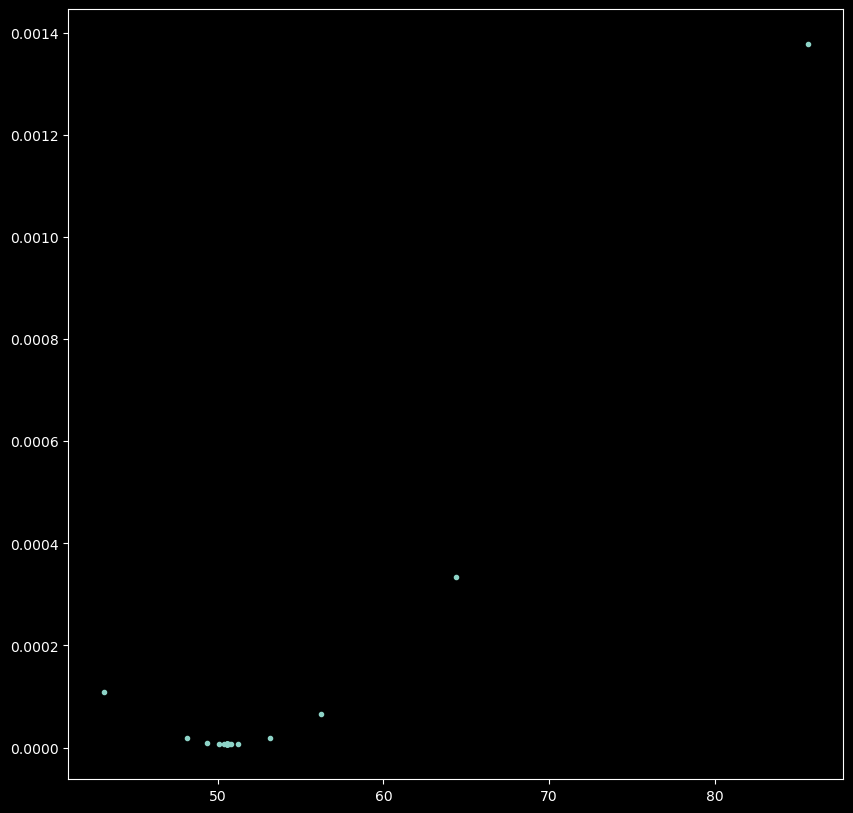

Exception in callback ELLx._update_status()
handle: <TimerHandle when=5211.256 ELLx._update_status()>
Traceback (most recent call last):
  File "c:\Users\Experiment\anaconda3\Lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\Experiment\anaconda3\Lib\site-packages\thorlabs_elliptec\__init__.py", line 413, in _update_status
    reply_data = self._write_command("gs")
                 ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Experiment\anaconda3\Lib\site-packages\thorlabs_elliptec\__init__.py", line 444, in _write_command
    self._port.write(bytearray(request_data + "\r\n", "ascii"))
  File "c:\Users\Experiment\anaconda3\Lib\site-packages\serial\serialwin32.py", line 317, in write
    raise SerialException("WriteFile failed ({!r})".format(ctypes.WinError()))
serial.serialutil.SerialException: WriteFile failed (PermissionError(13, 'Access is denied.', None, 5))


In [38]:
waveplateCal=AlignPwrMetertLib.WavePlateAngleCalibration(PwrMeterObj,RotaMountObj,30,120)
Xmin,yMin=waveplateCal.PerformWavePlateAlignment()
print(Xmin,yMin)
plt.plot(waveplateCal.Angles,waveplateCal.powerReading,'.')

del waveplateCal

## Set the Rotation Mounts to the optics zero point

In [30]:
RotaMountObj.AngleOffset[1]=21.872

In [63]:
RotaMountObj.SetAngle(0,0)
RotaMountObj.SetAngle(22.5,1)


(33.499, 22.499000000000024)

In [36]:
RotaMountObj.SetAngle(0)

(15.903, 0.004000000000001336)

In [8]:
RotaMountObj.SetAngle(20.5,1)

(42.368, 20.496000000000002)

## Set the rotation mount to a angle pair relation

In [58]:
RotaMountObj.SetAnglePair(0,1,5)

5 5.000999999999998 54.003
28.656780422709623 28.647 48.619


(5.000999999999998, 28.647)

# Lanuch the PiezoMount

In [6]:
PiezoMount=Piezolib.PiezoStrainGaugeObj()

0
1
A conection has been made to  KPC101 Piezo Controller
Setting Zero Point


## Test the Piezo mount by geting its current position

In [7]:
# print(PiezoMount.CurrentPostion)
# newPos=PiezoMount.SetPosition(10.003)
# print(newPos)
a=PiezoMount.GetPosition()
print(a)

-0.000610370189519944


In [45]:
PiezoMount.SetPosition(0.8401)

# Lauch TimeTagger Thread

In [7]:
del taggerObj

In [6]:
# del taggerObj
taggerObj = TimeTaggerMod.TimeTaggerInterface([1,2])

2
New trigger level: 0.22599999606609344
New trigger level: 0.22599999606609344


# change timetagger properties

In [12]:
taggerObj.setCountingTime(0.1*1e12)
taggerObj.setTriggerLevel(1, 0.268)
# taggerObj.setTriggerLevel(2, 0.113)
# taggerObj.setTriggerLevel(2, 0.3)

taggerObj.setBinWidth(1)
taggerObj.setBinNumber(3000)
taggerObj.setDelayTime(1,0)
print(taggerObj.DelayTime[0],taggerObj.DelayTime[1])

New trigger level: 0.2680000066757202
[0]
0
0
0 6200


In [9]:
import multiprocessing

arr = multiprocessing.Array('i', [1, 2, 3, 4, 5])
number_to_find = 3

indices = [i for i in range(len(arr)) if arr[i] == number_to_find]

if indices:
    print(f"Found {number_to_find} at indices {indices[0]}")
else:
    print(f"{number_to_find} not found in the array")

Found 3 at indices 2


In [117]:
taggerObj.setDelayTime(1)
print(taggerObj.DelayTime.value)

1


# run a trigger level sweep Need to put this into a function

New trigger level: 0.10000000149011612
28 0 0.1
New trigger level: 0.10499999672174454
20 1 0.10505050505050506
New trigger level: 0.11010000109672546
11 2 0.1101010101010101
New trigger level: 0.1151999980211258
17 3 0.11515151515151516
New trigger level: 0.12020000070333481
13 4 0.12020202020202021
New trigger level: 0.12520000338554382
14 5 0.12525252525252525
New trigger level: 0.13030000030994415
16 6 0.1303030303030303
New trigger level: 0.13539999723434448
10 7 0.13535353535353536
New trigger level: 0.1404000073671341
17 8 0.14040404040404042
New trigger level: 0.14550000429153442
13 9 0.14545454545454545
New trigger level: 0.15049999952316284
16 10 0.15050505050505053
New trigger level: 0.15549999475479126
18 11 0.15555555555555556
New trigger level: 0.16060000658035278
13 12 0.1606060606060606
New trigger level: 0.1657000035047531
12 13 0.16565656565656567
New trigger level: 0.17069999873638153
16 14 0.17070707070707072
New trigger level: 0.17569999396800995
10 15 0.1757575757

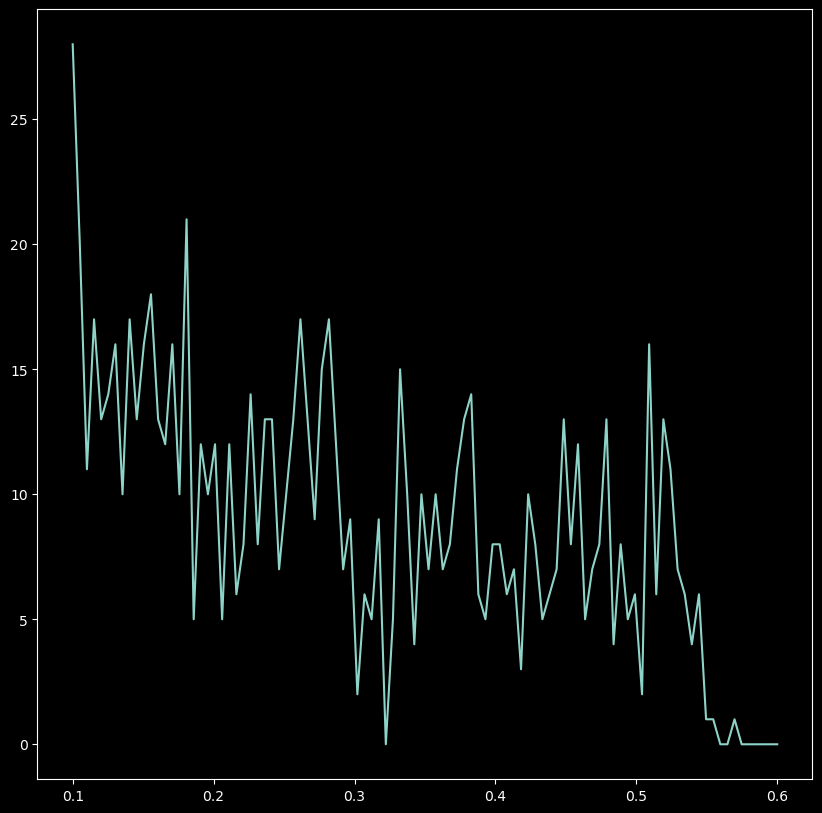

In [15]:
voltmin=0.1
voltmax=0.6
VoltCount=int(voltmax-voltmin/0.001)
VoltCount=100
TTchannel=3
voltageVal=np.linspace(voltmin,voltmax,VoltCount)
countdata_arr=np.zeros(VoltCount)
taggerObj.setSingleCaptureMode()
for ivolt in range(VoltCount):
    voltval=voltageVal[ivolt]
    taggerObj.setTriggerLevel(TTchannel, voltval)
    countsdata=taggerObj.getCoincidences()
    countdata_arr[ivolt]=countsdata[1]
    print(countsdata[1],ivolt,voltval)
taggerObj.setContinuousCaptureMode()
plt.plot(voltageVal,countdata_arr)

# plot a count graph or a correlation graph

4750
4.75e-09 4.75e-09 2.4025e-07
235500


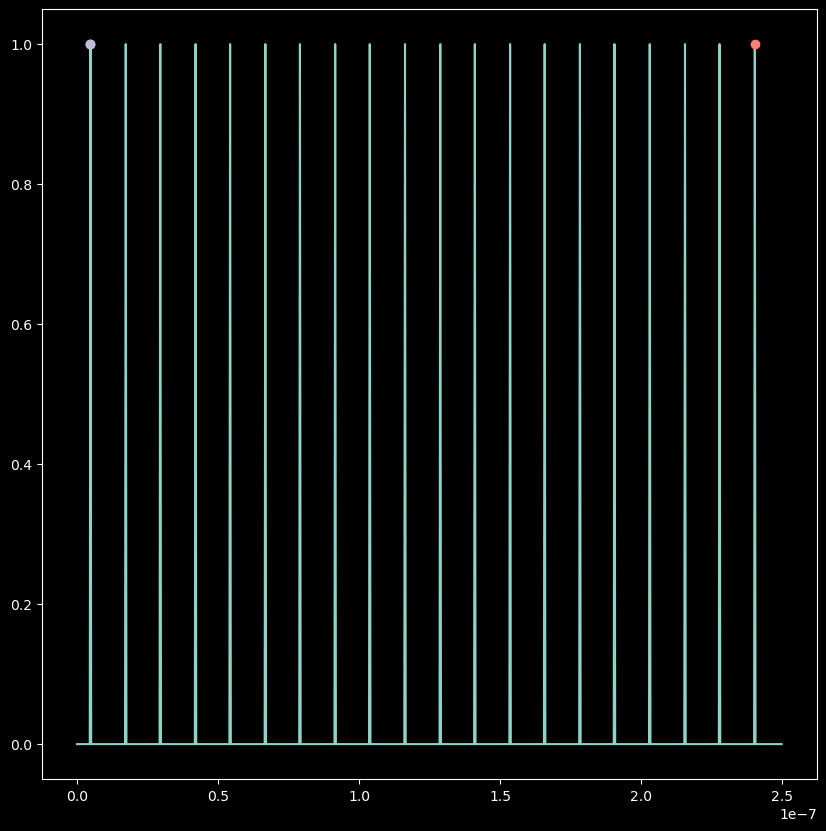

In [126]:
# CorrData=taggerObj.getCorrelatinoGraph()
CorrData=taggerObj.getCounterGraph()

plt.plot(CorrData[0,:]/1e12,CorrData[1,:])
maxIdax=np.argmax(CorrData[1,:])
print(CorrData[0,maxIdax])
idx_l,idx_r, fwhm=FWHMFunc.fwhm_1d(CorrData[1,:])

print(CorrData[0,idx_l]/1e12,CorrData[0,maxIdax]/1e12,CorrData[0,idx_r]/1e12)
print(CorrData[0,idx_r]-CorrData[0,idx_l])


plt.plot(CorrData[0,idx_l]/1e12,CorrData[1,idx_l],'.',markersize=12)
plt.plot(CorrData[0,maxIdax]/1e12,CorrData[1,maxIdax],'.',markersize=12)
plt.plot(CorrData[0,idx_r]/1e12,CorrData[1,idx_r],'.',markersize=12)



# Launch the timetagger that isn't running on thread

### create the time tagger object

In [28]:
createtagger=1
if(createtagger==1):
    tagger = TimeTagger.createTimeTagger()
else:
    TimeTagger.freeTimeTagger(tagger)

### Set global properties of the time tagger object 

In [29]:

#turn on the conditional filter
tagger.setConditionalFilter(trigger=[1,2,3], filtered=[8])
#tagger.setConditionalFilter(trigger=[1,2,3], filtered=[4])
#Turn off the conditional filter
# tagger.clearConditionalFilter()
sm = TimeTagger.SynchronizedMeasurements(tagger)
tagger.setInputDelay(1, 970)
tagger.setInputDelay(2, 900)
tagger.setInputDelay(3, 2650)
tagger.setInputDelay(8, 6200)


In [ ]:
tagger.getTriggerLevel(8)

0.5

# Make some correlation measurements classes

In [30]:
binCount=3000
channels=[1,2,3]
#channels=[1,2,3]
# ChannelCount=len(channels)
corr_list = list()
for ch in channels:
    corr_list.append(TimeTagger.Correlation(sm.getTagger(), channel_1=8, channel_2=ch, binwidth=1, n_bins=binCount))


corr_list.append(TimeTagger.Correlation(sm.getTagger(), channel_1=channels[0], channel_2=channels[1], binwidth=1, n_bins=binCount))
corr_list.append(TimeTagger.Correlation(sm.getTagger(), channel_1=channels[0], channel_2=channels[2], binwidth=1, n_bins=binCount))
corr_list.append(TimeTagger.Correlation(sm.getTagger(), channel_1=channels[1], channel_2=channels[2], binwidth=1, n_bins=binCount))
# corr_list.append(TimeTagger.Counter(sm.getTagger(),channels=[channels[0]],binwidth=1,n_values=binCount))
# corr_list.append(TimeTagger.Counter(sm.getTagger(),channels=[channels[1]],binwidth=1,n_values=binCount))
# corr_list.append(TimeTagger.Counter(sm.getTagger(),channels=[channels[2]],binwidth=1,n_values=binCount))

corr_list.append(TimeTagger.Countrate(sm.getTagger(),channels=[channels[0]]))
corr_list.append(TimeTagger.Countrate(sm.getTagger(),channels=[channels[1]]))
corr_list.append(TimeTagger.Countrate(sm.getTagger(),channels=[channels[2]]))




    
# for ch in channels:   
#     corr_list.append(TimeTaggerCustomObj.CustomCorrelationMeasurement(sm.getTagger(),[4], [ch], binwidth=1, n_bins=binCount,MeasurementType=1))
  
# corr_list.append(TimeTaggerCustomObj.CustomCorrelationMeasurement(sm.getTagger(),[8], channels, binwidth=1, n_bins=binCount,MeasurementType=100))
# corr_list.append(TimeTagger.FileWriter(sm.getTagger(),'dump1234.ttbin',[1,2,3,4]))
# ChannelCountTotal=len(corr_list)
ChannelCount=len(corr_list)

In [47]:
CounterTimebins_data,Couter_data=TimetaggerFunc.getCounts(tagger,clearbuffer=True, measurementChannel=1, binWidth=1000000000, binNum=300,countingTime=1)
counts=TimetaggerFunc.getCountrate(tagger, measurementChannel=1,countingTime=1)
print(counts)

[12754.]


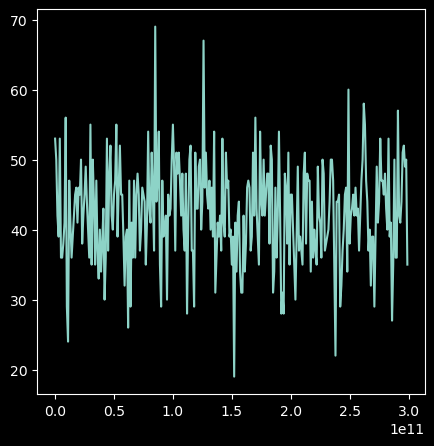

In [71]:
plt.plot(CounterTimebins_data,np.squeeze(Couter_data))

In [31]:
ChannelCount

7

# Take a single correlation measurement to make sure the delay is correct

9
909.4140334593633 918.0
871.9016481327556 911.0
898.6228573480382 909.0
6.546296296296297 70.0
-4.97979797979798 -5.0
-10.23046875 16.0


<Figure size 500x500 with 0 Axes>

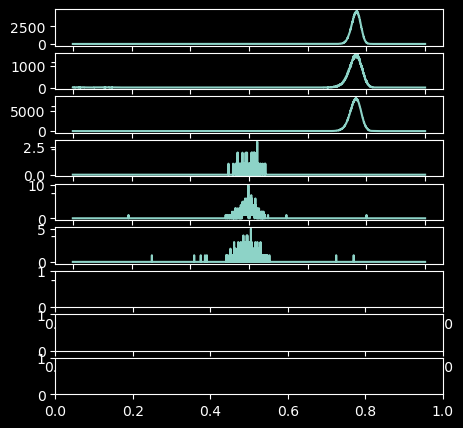

In [35]:
#check a single correlation measurement
# tagger.setInputDelay(3, 0)
# tagger.setInputDelay(1, 8450 + 400)
# tagger.setInputDelay(2, 8200 + 450)
# tagger.setInputDelay(1, 8000-625)
# tagger.setInputDelay(2, 8000-450)
# tagger.setInputDelay(1, 5500)
# tagger.setInputDelay(2, 5410)
# tagger.setInputDelay(3, 2660)
# tagger.setInputDelay(1, 5600)
# tagger.setInputDelay(2, 5500)
# tagger.setInputDelay(3, 3600)
# tagger.setInputDelay(1, 4200)
# tagger.setInputDelay(2, 4090)
# tagger.setInputDelay(3, 2795)
tagger.setInputDelay(1, 12730)
tagger.setInputDelay(2, 12500)
tagger.setInputDelay(3, 11350)
#tagger.setInputDelay(1, 2150-586-6-6+30+6)
#tagger.setInputDelay(2, 1800-317+12-19+4+10)

tagger.setInputDelay(8, 0)     #this is the pump
CountTime=10
timeData,CorrData, CorrDataNorm=  TimetaggerFunc.GetCorrelationAndCountsdata_SynMulti(sm,corr_list,channels,CountTime,3000,PlotResutls=True)

# If you want to get the time delay you can use either of the lines below
# TimetaggerFunc.CalculateTimeDelay(timeData,CorrDataNorm)
AvgTimeDelay_0,PeakTimeDelay_0 = TimetaggerFunc.CalculateTimeDelay(timeData[0,:],CorrData[0,:])
print(AvgTimeDelay_0,PeakTimeDelay_0)
AvgTimeDelay_1,PeakTimeDelay_1 =TimetaggerFunc.CalculateTimeDelay(timeData[0,:],CorrData[1,:])
print(AvgTimeDelay_1,PeakTimeDelay_1)
AvgTimeDelay_2,PeakTimeDelay_2 =TimetaggerFunc.CalculateTimeDelay(timeData[0,:],CorrData[2,:])
print(AvgTimeDelay_2,PeakTimeDelay_2)
AvgTimeDelay_3,PeakTimeDelay_3 =TimetaggerFunc.CalculateTimeDelay(timeData[0,:],CorrData[3,:])
print(AvgTimeDelay_3,PeakTimeDelay_3)
AvgTimeDelay_4,PeakTimeDelay_4 =TimetaggerFunc.CalculateTimeDelay(timeData[0,:],CorrData[4,:])
print(AvgTimeDelay_4,PeakTimeDelay_4)
AvgTimeDelay_5,PeakTimeDelay_5 =TimetaggerFunc.CalculateTimeDelay(timeData[0,:],CorrData[5,:])
print(AvgTimeDelay_5,PeakTimeDelay_5)




In [34]:
CorrData[8,:]

array([15387.26666667, 15387.26666667, 15387.26666667, ...,
       15387.26666667, 15387.26666667, 15387.26666667])

# Read Raw tag files


In [21]:
#Read the Raw tages
tags=TimetaggerFunc.ReadRawTagFiles(config.PATH_TO_TIMETAGGER_FOLDER+"Data\\RawTimeTags")
#Move the Raw tags
# TimetaggerFunc.MoveRawTags(config.PATH_TO_TIMETAGGER_FOLDER+"Data\\RawTimeTags","Data\\RawTags\\")

Available RAM: 4.77 GB
File can be loaded. File size is 0.3346545919775963 GB


[1 2 3 4]


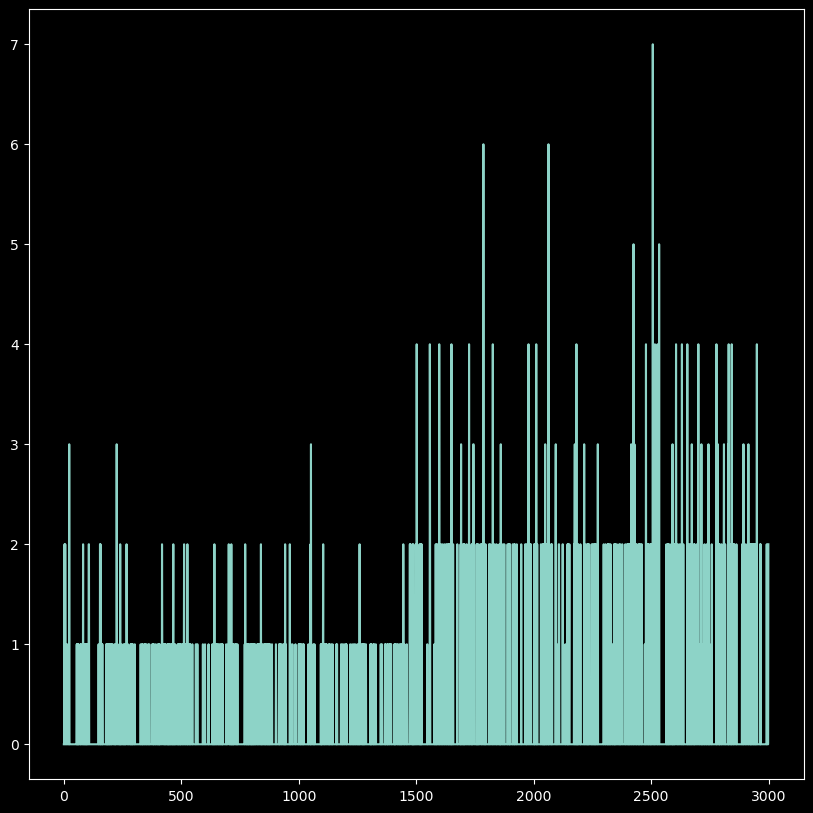

In [25]:
# Pass the Raw tags to a function for processing/performing measurements
binCount=3000
data = np.zeros((binCount), dtype=np.uint64)
unique_rows = np.unique(tags['channel'], axis=0)
print(unique_rows)
_,ch1,ch2=TimeTaggerCustomObj.fast_process_Correlations(tags,
                data,
                unique_rows[-1],          
                unique_rows[0],
                binCount,
                1,
                0)
print(ch1,ch2)
plt.plot(data)

In [99]:
# Setup distance array for peizo mount
CountTime=60
maxdist=2 # this is in micros
mindist=0 # this is in micros
distSpacing_ideal =0.1 #can go as low as 0.01
distCount=int((maxdist-mindist)/distSpacing_ideal)
distArr_ideal=np.linspace(mindist,maxdist,distCount)
distSpacing=distArr_ideal[1]-distArr_ideal[0]
print(distCount,distCount/CountTime/60,distSpacing_ideal,distSpacing)
# distCount=10

20 0.005555555555555555 0.1 0.10526315789473684


# Do Experiment Measurment

In [22]:
#RotaMountObj.SetAngle(0,0)
#RotaMountObj.SetAngle(0,1)

# Mount1Angle = RotaMountObj.SetAngle(0,0)
# Mount2Angle = RotaMountObj.SetAngle(45,1)

#Mount1Angle,Mount2Angle=RotaMountObj.SetAnglePair(0,1,5)

# for manual mounts, insert values by hand

Mount1Angle = 5.000
Mount2Angle = 4.834

In [24]:
# Setup distance array for peizo mount
CountTime=60
maxdist=4 # this is in micros
mindist=0 # this is in micros
distSpacing_ideal =0.1 #can go as low as 0.01
distCount=int((maxdist-mindist)/distSpacing_ideal)
distArr_ideal=np.linspace(mindist,maxdist,distCount)
distSpacing=distArr_ideal[1]-distArr_ideal[0]
print(distCount,distSpacing_ideal,distSpacing)
# distCount=10

#Set mount to zero
PiezoMount.SetPosition(0.0001)

# make all the arrays for the data
timeDataAll=np.zeros((ChannelCount,binCount,distCount))
MeasurementDataAll=np.zeros((ChannelCount,binCount,distCount))
MeasurementDataNormAll=np.zeros((ChannelCount,binCount,distCount))
# CorrDataAdd=np.zeros((binCount,distCount))
# CorrDataNormAdd=np.zeros((binCount,distCount))
distArr_measured=np.zeros((distCount))
PlotDuringMeasument=True

if (PlotDuringMeasument):
    plt.figure(1,figsize=(4,4))
    
for idist in range(distCount):
    
    #################################
    #take correlations measurment
    #################################
    timeData , MeasurementData, MeasurementDataNorm = TimetaggerFunc.GetCorrelationAndCountsdata_SynMulti(sm,corr_list,channels,CountTime,binCount)
    timeDataAll[:,:,idist]=timeData
    MeasurementDataAll[:,:,idist]= MeasurementData
    MeasurementDataNormAll[:,:,idist]=MeasurementDataNorm
    # CorrDataAdd[:,idist]=np.sum(CorrData,axis=0)
    # CorrDataNormAdd[:,idist]=np.sum(CorrDataNorm,axis=0)
    print(PiezoMount.GetPosition())
    
    #################################
    # Move the the BeamSplitter
    #################################
    if (idist==0):
        distArr_measured[idist]=float(str(PiezoMount.GetPosition()))
        print(distArr_measured[idist],distArr_ideal[idist])
    else:
       
        distArr_measured[idist]=float(str(PiezoMount.SetPosition(distArr_ideal[idist])))
        print(distArr_measured[idist],distArr_ideal[idist])
        print(PiezoMount.GetPosition())
        
    #################################
    #save the data While we are going. This is really ineffiecent but dont really care at the moment
    #################################
    np.savez_compressed('Data\\batch_data.npz',
                        timeDataAll=timeDataAll, 
                        CorrDataAll=MeasurementDataAll,
                        CorrDataNormAll=MeasurementDataNormAll,
                        # CorrDataAdd=CorrDataAdd,
                        # CorrDataNormAdd=CorrDataNormAdd,
                        distArr_ideal=distArr_ideal,
                        distArr_measured=distArr_measured,
                        AngleOfFirstWaveplate=Mount1Angle,
                        AngleOfSecondWaveplate=Mount2Angle
                        )
    TimetaggerFunc.MoveRawTags(config.PATH_TO_TIMETAGGER_FOLDER+"Data\\RawTimeTags","Data\\RawTags\\RawtagMountPos"+str(idist)+"\\")
    # save the data So far using pickle. I think npz is faster
    # with open('Data\\batch_data.pkl', 'wb') as f:
    #     pickle.dump([timeDataAll, CorrDataAll,CorrDataNormAll,CorrDataAdd,CorrDataNormAdd], f)
    
    #################################
    # plot the result while we are giong
    #################################
    # if (PlotDuringMeasument):
    #     plt.subplot(1,2,1)
    #     plt.imshow(CorrDataAdd,aspect='auto')
    #     plt.subplot(1,2,2)
    #     plt.imshow(CorrDataNormAdd,aspect='auto')
    #     plt.show
        
# 


40 0.1 0.10256410256410256
9
-0.000610370189519944
-0.000610370189519944 0.0
9
0
0.102542191839351 0.10256410256410256
0.102542191839351
9
0.102542191839351
0.205084383678701 0.20512820512820512
0.205084383678701
9
0.205084383678701
0.308236945707572 0.3076923076923077
0.308236945707572
9
0.307626575518052
0.410168767357402 0.41025641025641024
0.410168767357402
9
0.410168767357402
0.512710959196753 0.5128205128205128
0.512710959196753
9
0.512710959196753
0.615253151036104 0.6153846153846154
0.615253151036104
9
0.615253151036104
0.717795342875454 0.717948717948718
0.717795342875454
9
0.717795342875454
0.820947904904324 0.8205128205128205
0.820947904904324
9
0.820337534714804
0.922879726554155 0.923076923076923
0.922879726554155
9
0.922879726554155
1.02542191839351 1.0256410256410255
1.02542191839351
9
1.02603228858303
1.12796411023286 1.1282051282051282
1.12796411023286
9
1.12796411023286
1.23050630207221 1.2307692307692308
1.23050630207221
9
1.23050630207221
1.33304849391156 1.33333333

<Figure size 400x400 with 0 Axes>

## Angle Sweep 

In [35]:



step_angle = 0.5
start_angle = 0.5
stop_angle = 20 + step_angle
angleCount=int((stop_angle-start_angle)/step_angle)


angle_arr=np.linspace(start_angle,stop_angle,angleCount)

for iangle in range(angleCount): 
    Mount1Angle, Mount2Angle = RotaMountObj.SetAnglePair(0,1,angle_arr[iangle])
    
    # Setup distance array for peizo mount
    CountTime=40
    maxdist=2 # this is in micros
    mindist=0 # this is in micros
    distSpacing_ideal =0.05 #can go as low as 0.01
    distCount=int((maxdist-mindist)/distSpacing_ideal)
    distArr_ideal=np.linspace(mindist,maxdist,distCount)
    distSpacing=distArr_ideal[1]-distArr_ideal[0]
    print(distCount,distSpacing_ideal,distSpacing)
    # distCount=10

    #Set mount to zero
    PiezoMount.SetPosition(0.0001)

    # make all the arrays for the data
    timeDataAll=np.zeros((ChannelCount,binCount,distCount))
    CorrDataAll=np.zeros((ChannelCount,binCount,distCount))
    CorrDataNormAll=np.zeros((ChannelCount,binCount,distCount))
    CorrDataAdd=np.zeros((binCount,distCount))
    CorrDataNormAdd=np.zeros((binCount,distCount))
    distArr_measured=np.zeros((distCount))
    PlotDuringMeasument=True

    if (PlotDuringMeasument):
        plt.figure(1,figsize=(4,4))
        
    for idist in range(distCount):
        
        #################################
        #take correlations measurment
        #################################
        timeData , CorrData, CorrDataNorm = TimetaggerFunc.GetCorrelationdata(sm,corr_list,CountTime,binCount)
        timeDataAll[:,:,idist]=timeData
        CorrDataAll[:,:,idist]= CorrData
        CorrDataNormAll[:,:,idist]=CorrDataNorm
        CorrDataAdd[:,idist]=np.sum(CorrData,axis=0)
        CorrDataNormAdd[:,idist]=np.sum(CorrDataNorm,axis=0)
        
        #################################
        # Move the the BeamSplitter
        #################################
        if (idist==0):
            distArr_measured[idist]=float(str(PiezoMount.GetPosition()))
            print(distArr_measured[idist],distArr_ideal[idist])
        else:
        
            distArr_measured[idist]=float(str(PiezoMount.SetPosition(distArr_ideal[idist])))
            print(distArr_measured[idist],distArr_ideal[idist])
            print(PiezoMount.GetPosition())
            
        #################################
        #save the data While we are going. This is really ineffiecent but dont really care at the moment
        #################################
        
        
        np.savez_compressed('Data\\AngleSweep\\batch_data_angle_' + str(iangle),
                            timeDataAll=timeDataAll, CorrDataAll=CorrDataAll
                            ,CorrDataNormAll=CorrDataNormAll
                            ,CorrDataAdd=CorrDataAdd
                            ,CorrDataNormAdd=CorrDataNormAdd
                            ,distArr_ideal=distArr_ideal
                            ,distArr_measured=distArr_measured
                            ,AngleOfFirstWaveplate=Mount1Angle
                            ,AngleOfSecondWaveplate=Mount2Angle
                            )
        # save the data So far using pickle. I think npz is faster
        # with open('Data\\batch_data.pkl', 'wb') as f:
        #     pickle.dump([timeDataAll, CorrDataAll,CorrDataNormAll,CorrDataAdd,CorrDataNormAdd], f)
        
        #################################
        # plot the result while we are giong
        #################################
        if (PlotDuringMeasument):
            plt.subplot(1,2,1)
            plt.imshow(CorrDataAdd,aspect='auto')
            plt.subplot(1,2,2)
            plt.imshow(CorrDataNormAdd,aspect='auto')
            plt.show
    






SyntaxError: invalid syntax (3876648163.py, line 8)

In [36]:
#testing anglesweep filenames

step_angle = 0.5
start_angle = 0.5
stop_angle = 20 + step_angle
angleCount=int((stop_angle-start_angle)/step_angle)


angle_arr=np.linspace(start_angle,stop_angle,angleCount)

for iangle in range(angleCount):
    #filenameiter = f"{'sweepdata'}_{iangle:.1f}.npz"
    np.savez_compressed('Data\\AngleSweep\\batch_data_angle_' + str(iangle))      ##checking saving...will delete the files 
    




# Grabbing correlations and raw tags using streamtags

In [36]:

def _intvector(chs):
    iv = TimeTagger.IntVector()
    for c in chs:
        iv.push_back(int(c))
    return iv

def pick_stream_channels(tagger):
    """Choose which channels to stream; prefer filtered negatives if available."""
    try:
        cfg = tagger.getConfiguration()
        regs = set(cfg.get("registered channels", []))
    except Exception:
        # fallback: try common sets; stream will ignore non-existent ones
        regs = set([1,2,3,8,-1,-2,-3])

    # Prefer filtered negatives + pump if they exist; else positives + pump; else whatever is present
    if {-1,-2,-3,8}.issubset(regs): return [-1,-2,-3,8]
    if { 1, 2, 3,8}.issubset(regs): return [ 1, 2, 3,8]
    cand = [-1,-2,-3,1,2,3,8]
    return [c for c in cand if c in regs]

def _decode_buffer_with_timeout(buf, timeout_s=0.5):
    """
    Try to decode a TimeTagStreamBuffer into (ts, ch, ty) with a watchdog timeout.
    Returns (ts, ch, ty) or (None, None, None) on timeout/failure.
    """
    out = {}

    def _worker():
        try:
            # Prefer fast path if available
            if hasattr(buf, "toNumpy"):
                arr = buf.toNumpy()
                ts = arr["time"].astype(np.int64,  copy=False)
                ch = arr["channel"].astype(np.int32, copy=False)
                ty = arr["type"].astype(np.uint8,  copy=False) if "type" in arr.dtype.names else None
                out["ts"], out["ch"], out["ty"] = ts, ch, ty
                return

            # Legacy getters (may block on some SDKs)
            ts = None
            for ts_name in ("getTimestampsPs", "getTimestamps", "getTimes"):
                if hasattr(buf, ts_name):
                    ts = getattr(buf, ts_name)()
                    break
            if ts is None:
                return
            ch = buf.getChannels() if hasattr(buf, "getChannels") else None
            ty = buf.getTypes()    if hasattr(buf, "getTypes")    else None

            # Normalize to numpy
            ts = np.asarray(ts, dtype=np.int64)
            ch = np.asarray(ch, dtype=np.int32) if ch is not None else None
            ty = np.asarray(ty, dtype=np.uint8) if ty is not None else None
            out["ts"], out["ch"], out["ty"] = ts, ch, ty
        except Exception:
            # leave out empty => signals failure
            return

    t = threading.Thread(target=_worker, daemon=True)
    t.start()
    t.join(timeout_s)
    if t.is_alive():
        return None, None, None
    return out.get("ts"), out.get("ch"), out.get("ty")

def stream_capture_synchronously(tagger, channels, status_prefix="[stream]",
                                 per_buffer_timeout_s=0.5, overall_timeout_s=5.0):
    """
    Start TimeTagStream now. Return stop_and_drain() that will:
      - stop the stream
      - drain all buffers with per-buffer decode timeout
      - abort draining after overall_timeout_s to avoid hangs
    """
    iv = _intvector(channels)
    stream = TimeTagger.TimeTagStream(tagger, int(2_000_000), iv)
    if hasattr(stream, "start"): stream.start()
    print(f"{status_prefix} START on {channels}; will drain after SM window")

    def stop_and_drain():
        if hasattr(stream, "stop"): stream.stop()
        total = 0
        times_list, chans_list, types_list = [], [], []
        started = time.time()
        skipped = 0
        while True:
            if time.time() - started > overall_timeout_s:
                print(f"{status_prefix} drain timeout after {overall_timeout_s}s (kept={total}, skipped={skipped})")
                break
            buf = stream.getData()  # returns next buffer or None
            if buf is None:
                break
            ts, ch, ty = _decode_buffer_with_timeout(buf, timeout_s=per_buffer_timeout_s)
            if ts is None or ch is None:
                skipped += 1
                continue
            if ts.size:
                total += ts.size
                times_list.append(ts)
                chans_list.append(ch)
                if ty is not None:
                    types_list.append(ty)

        ts_all = np.concatenate(times_list) if times_list else np.empty(0, np.int64)
        ch_all = np.concatenate(chans_list) if chans_list else np.empty(0, np.int32)
        ty_all = np.concatenate(types_list) if types_list else None
        uniq = np.unique(ch_all) if ch_all.size else []
        print(f"{status_prefix} STOP; drained {total} tags; skipped {skipped} buffers; unique chans: {uniq}")
        return ts_all, ch_all, ty_all

    return stop_and_drain


20 0.1 0.10526315789473684
[stream] chosen channels: [1, 2, 3, 8]
[stream pos 0] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 0] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 0] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 0] saved raw tags → Data\RawTags\RawtagMountPos0\stream_tags_pos_0.npz
0
0.0 0.0


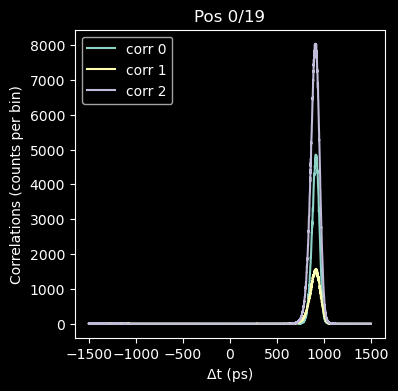

[stream pos 1] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 1] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 1] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 1] saved raw tags → Data\RawTags\RawtagMountPos1\stream_tags_pos_1.npz
0
0.10498367259743 0.10526315789473684
0.10498367259743


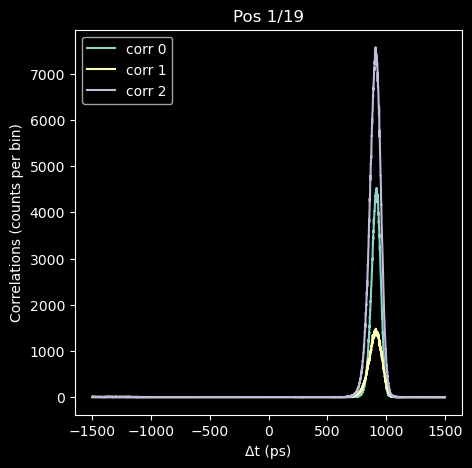

[stream pos 2] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 2] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 2] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 2] saved raw tags → Data\RawTags\RawtagMountPos2\stream_tags_pos_2.npz
0.10498367259743
0.210577715384381 0.21052631578947367
0.210577715384381


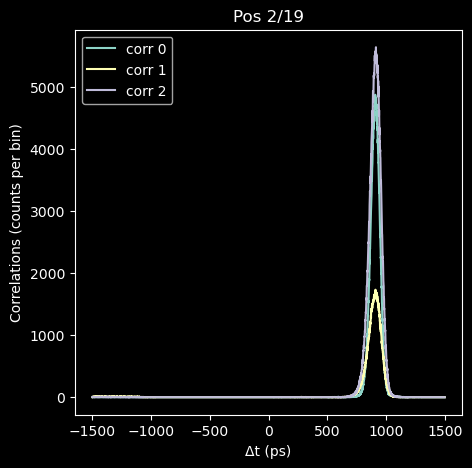

[stream pos 3] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 3] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 3] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 3] saved raw tags → Data\RawTags\RawtagMountPos3\stream_tags_pos_3.npz
0.210577715384381
0.315561387981811 0.3157894736842105
0.315561387981811


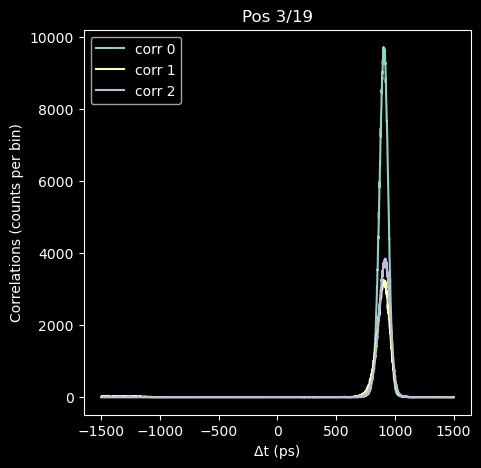

[stream pos 4] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 4] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 4] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 4] saved raw tags → Data\RawTags\RawtagMountPos4\stream_tags_pos_4.npz
0.315561387981811
0.421765800958281 0.42105263157894735
0.421765800958281


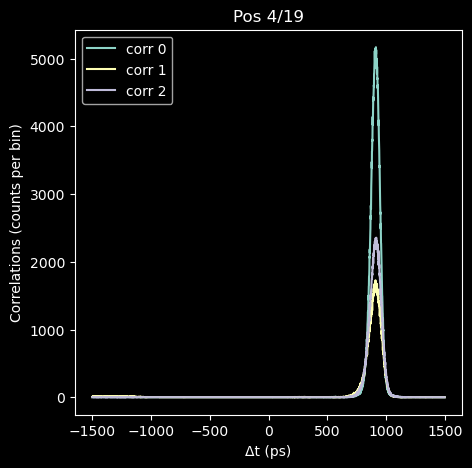

[stream pos 5] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 5] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 5] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 5] saved raw tags → Data\RawTags\RawtagMountPos5\stream_tags_pos_5.npz
0.421155430768761
0.526139103366192 0.5263157894736842
0.526139103366192


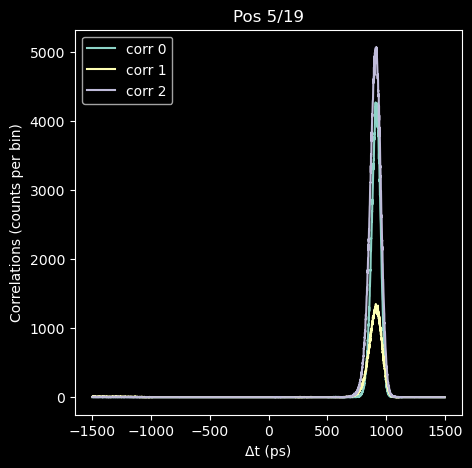

[stream pos 6] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 6] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 6] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 6] saved raw tags → Data\RawTags\RawtagMountPos6\stream_tags_pos_6.npz
0.526139103366192
0.631733146153142 0.631578947368421
0.631733146153142


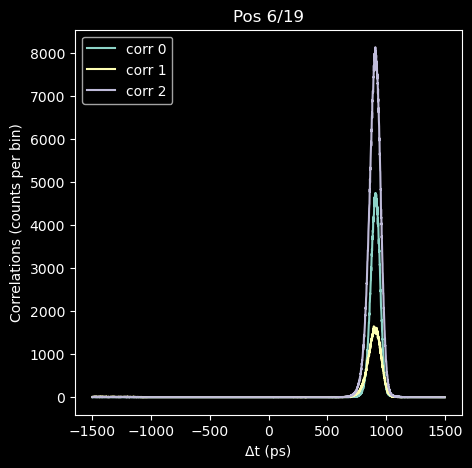

[stream pos 7] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 7] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 7] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 7] saved raw tags → Data\RawTags\RawtagMountPos7\stream_tags_pos_7.npz
0.631122775963622
0.736716818750572 0.7368421052631579
0.736716818750572


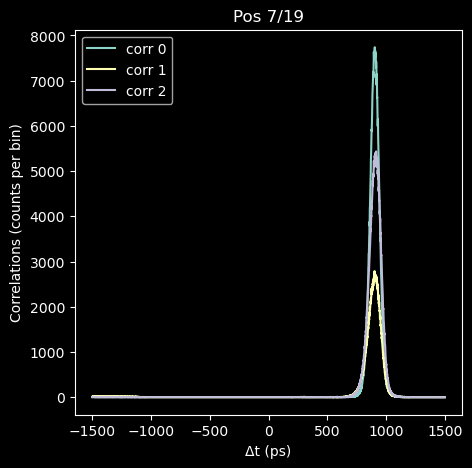

[stream pos 8] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 8] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 8] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 8] saved raw tags → Data\RawTags\RawtagMountPos8\stream_tags_pos_8.npz
0.736716818750572
0.842310861537522 0.8421052631578947
0.842310861537522


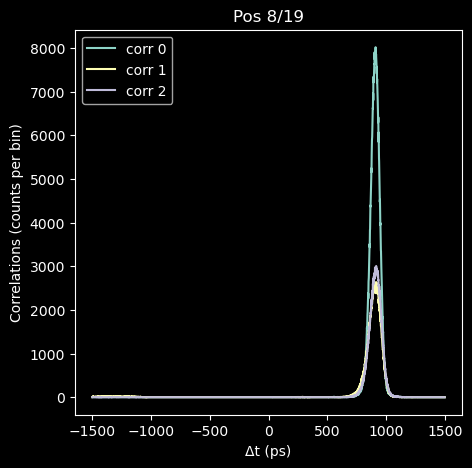

[stream pos 9] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 9] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 9] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 9] saved raw tags → Data\RawTags\RawtagMountPos9\stream_tags_pos_9.npz
0.842921231727042
0.947294534134953 0.9473684210526315
0.947294534134953


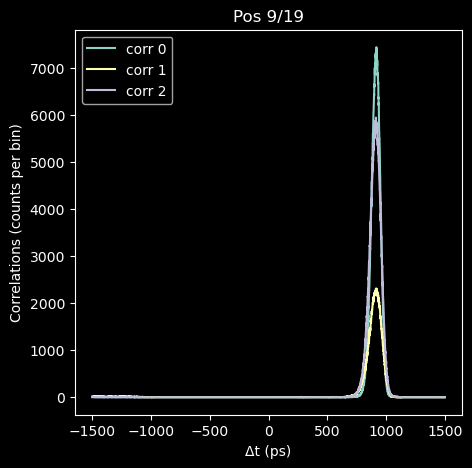

[stream pos 10] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 10] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 10] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 10] saved raw tags → Data\RawTags\RawtagMountPos10\stream_tags_pos_10.npz
0.947294534134953
1.05227820673238 1.0526315789473684
1.05227820673238


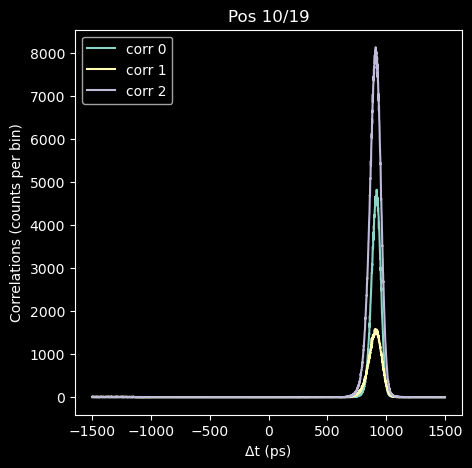

[stream pos 11] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 11] drain timeout after 5.0s (kept=1236579, skipped=0)
[stream pos 11] STOP; drained 1236579 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 11] saved raw tags → Data\RawTags\RawtagMountPos11\stream_tags_pos_11.npz
1.0528885769219
1.15787224951933 1.1578947368421053
1.15787224951933


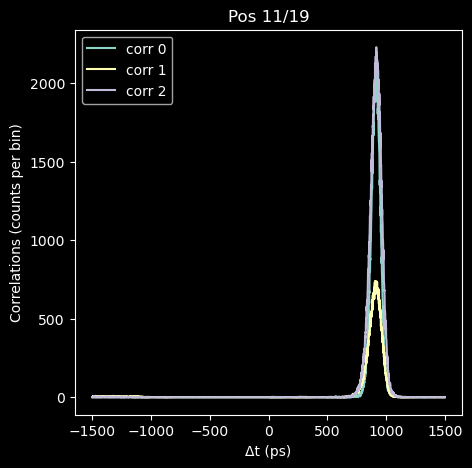

[stream pos 12] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 12] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 12] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 12] saved raw tags → Data\RawTags\RawtagMountPos12\stream_tags_pos_12.npz
1.15787224951933
1.26285592211676 1.263157894736842
1.26285592211676


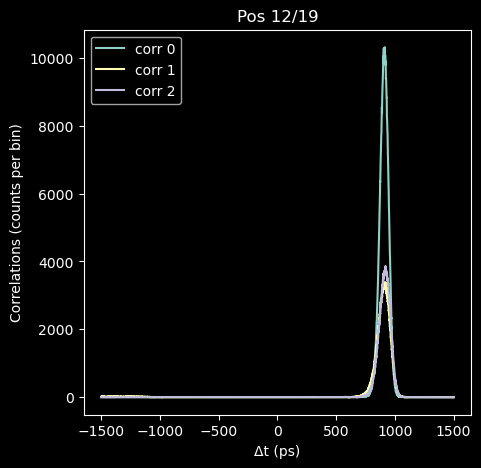

[stream pos 13] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 13] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 13] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 13] saved raw tags → Data\RawTags\RawtagMountPos13\stream_tags_pos_13.npz
1.26285592211676
1.36844996490371 1.3684210526315788
1.36844996490371


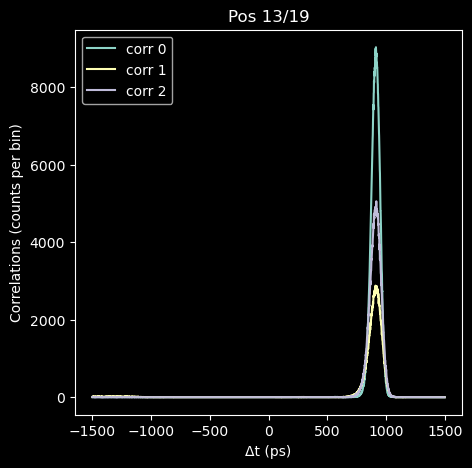

[stream pos 14] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 14] drain timeout after 5.0s (kept=633440, skipped=0)
[stream pos 14] STOP; drained 633440 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 14] saved raw tags → Data\RawTags\RawtagMountPos14\stream_tags_pos_14.npz
1.36844996490371
1.47343363750114 1.4736842105263157
1.47343363750114


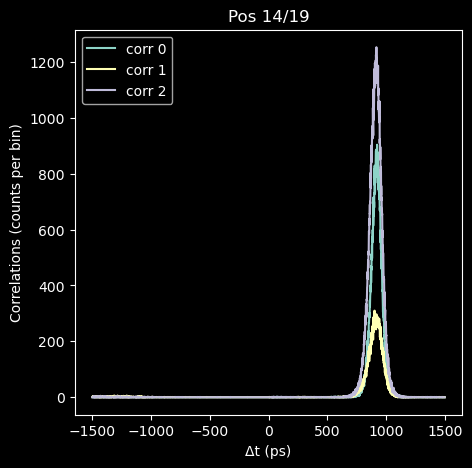

[stream pos 15] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 15] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 15] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 15] saved raw tags → Data\RawTags\RawtagMountPos15\stream_tags_pos_15.npz
1.47343363750114
1.57902768028809 1.5789473684210527
1.57902768028809


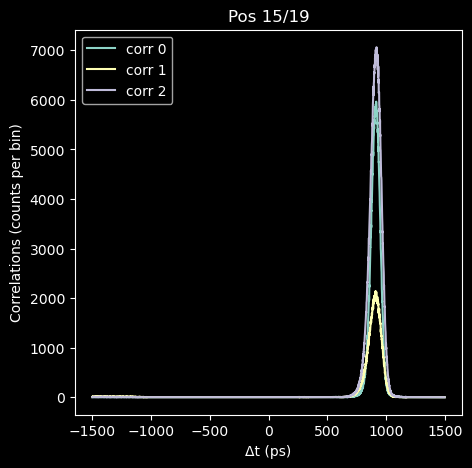

[stream pos 16] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 16] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 16] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 16] saved raw tags → Data\RawTags\RawtagMountPos16\stream_tags_pos_16.npz
1.57902768028809
1.68401135288553 1.6842105263157894
1.68401135288553


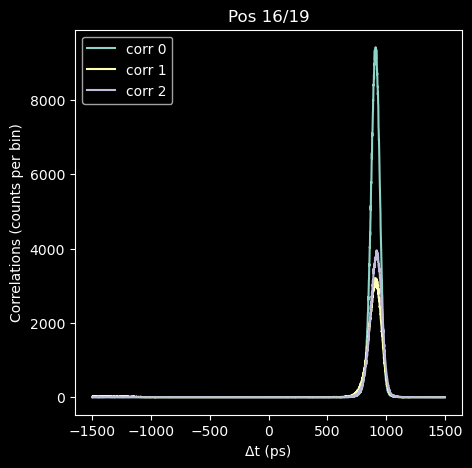

[stream pos 17] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 17] drain timeout after 5.0s (kept=162430, skipped=0)
[stream pos 17] STOP; drained 162430 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 17] saved raw tags → Data\RawTags\RawtagMountPos17\stream_tags_pos_17.npz
1.68401135288553
1.78960539567248 1.789473684210526
1.78960539567248


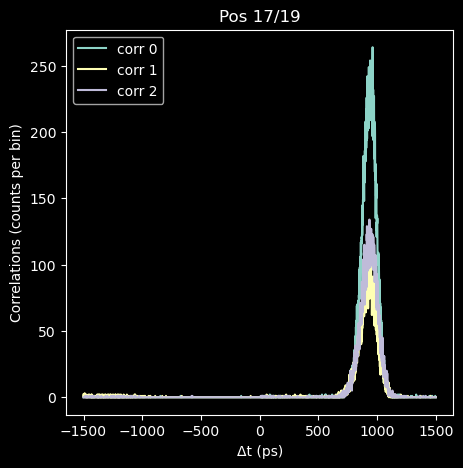

[stream pos 18] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 18] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 18] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 18] saved raw tags → Data\RawTags\RawtagMountPos18\stream_tags_pos_18.npz
1.78960539567248
1.89458906826991 1.894736842105263
1.89458906826991


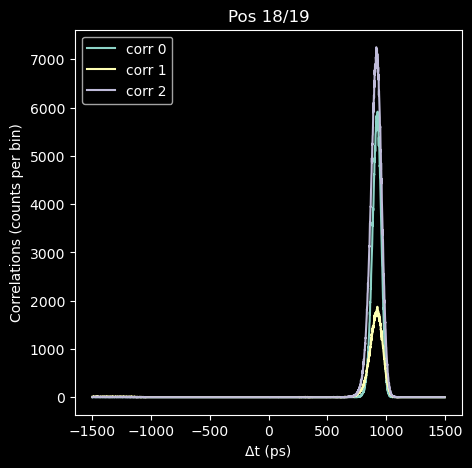

[stream pos 19] START on [1, 2, 3, 8]; will drain after SM window
9
[stream pos 19] drain timeout after 5.0s (kept=2000000, skipped=0)
[stream pos 19] STOP; drained 2000000 tags; skipped 0 buffers; unique chans: [1 2 3 8]
[stream pos 19] saved raw tags → Data\RawTags\RawtagMountPos19\stream_tags_pos_19.npz
1.89458906826991
2.00018311105686 2.0
2.00018311105686


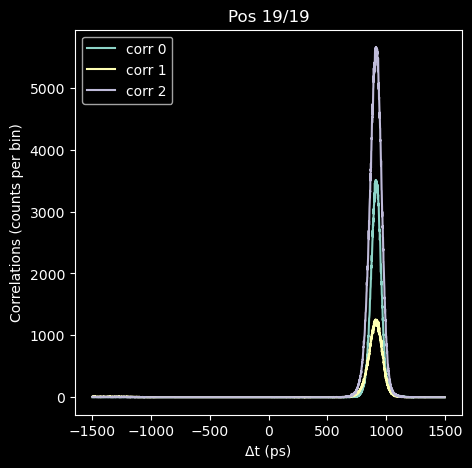

In [37]:
Mount1Angle = 0.000
Mount2Angle = 0.000

CountTime=10
maxdist=2  # micros
mindist=0  # micros
distSpacing_ideal = 0.1
distCount = int((maxdist - mindist) / distSpacing_ideal)
distArr_ideal = np.linspace(mindist, maxdist, distCount)
distSpacing = distArr_ideal[1] - distArr_ideal[0]
print(distCount, distSpacing_ideal, distSpacing)

# Set mount to zero
PiezoMount.SetPosition(0.0001)

# make all the arrays for the data (unchanged)
timeDataAll            = np.zeros((ChannelCount, binCount, distCount))
MeasurementDataAll     = np.zeros((ChannelCount, binCount, distCount))
MeasurementDataNormAll = np.zeros((ChannelCount, binCount, distCount))
distArr_measured       = np.zeros((distCount))
PlotDuringMeasument    = True

if (PlotDuringMeasument):
    plt.figure(1, figsize=(4,4))

# choose channels to stream from THIS device/tagger
tagger_for_stream   = sm.getTagger()
channels_to_stream  = pick_stream_channels(tagger_for_stream)
print("[stream] chosen channels:", channels_to_stream)

# base folder for per-position raw stream dumps
RAW_BASE = os.path.join("Data", "RawTags")
os.makedirs(RAW_BASE, exist_ok=True)

for idist in range(distCount):

    #################################
    # take correlations measurement (60 s) + stream raw tags concurrently
    #################################
    # 1) per-position folder for raw tags
    pos_dir = os.path.join(RAW_BASE, f"RawtagMountPos{idist}")
    os.makedirs(pos_dir, exist_ok=True)

    # 2) start stream BEFORE the blocking SM call
    stop_and_drain = stream_capture_synchronously(
        tagger_for_stream,
        channels_to_stream,
        status_prefix=f"[stream pos {idist}]"
    )

    # 3) your original blocking measurement (unchanged)
    timeData, MeasurementData, MeasurementDataNorm = TimetaggerFunc.GetCorrelationAndCountsdata_SynMulti(
        sm, corr_list, channels, CountTime, binCount, PlotResutls=False
    )

    # 4) stop stream & drain ALL buffers, then save per-position NPZ
    timestamps_ps, channel_ids, event_types = stop_and_drain()
    raw_npz = os.path.join(pos_dir, f"stream_tags_pos_{idist}.npz")
    np.savez_compressed(
        raw_npz,
        timestamps_ps=timestamps_ps,
        channel_ids=channel_ids,
        event_types=(event_types if event_types is not None else np.array([], dtype=np.uint8)),
        channels_streamed=np.array(channels_to_stream, dtype=np.int32),
        count_time_s=np.array([CountTime], dtype=np.float64)
    )
    print(f"[stream pos {idist}] saved raw tags → {raw_npz}")

    # 5) store your correlation results (unchanged)
    timeDataAll[:,:,idist]            = timeData
    MeasurementDataAll[:,:,idist]     = MeasurementData
    MeasurementDataNormAll[:,:,idist] = MeasurementDataNorm

    print(PiezoMount.GetPosition())

    #################################
    # Move the the BeamSplitter (unchanged)
    #################################
    if (idist==0):
        distArr_measured[idist] = float(str(PiezoMount.GetPosition()))
        print(distArr_measured[idist], distArr_ideal[idist])
    else:
        distArr_measured[idist] = float(str(PiezoMount.SetPosition(distArr_ideal[idist])))
        print(distArr_measured[idist], distArr_ideal[idist])
        print(PiezoMount.GetPosition())
    
    time.sleep(2) # sleep time of 2 s for piezo stage movement and stabilisation

    #################################
    # live plot (unchanged)
    #################################
    if PlotDuringMeasument:
        plt.clf()
        # if your original plot used specific traces, keep them; this matches prior behavior
        for k in range(min(ChannelCount, 3)):  # typically 8–1, 8–2, 8–3 are first three
            plt.plot(timeData[k,:], MeasurementDataAll[k,:,idist], label=f'corr {k}')
        plt.xlabel("Δt (ps)")
        plt.ylabel("Correlations (counts per bin)")
        plt.title(f"Pos {idist}/{distCount-1}")
        plt.legend()
        plt.pause(0.01)

    #################################
    # rolling save (unchanged)
    #################################
    np.savez_compressed(
        'Data\\batch_data.npz',
        timeDataAll=timeDataAll, 
        CorrDataAll=MeasurementDataAll,
        CorrDataNormAll=MeasurementDataNormAll,
        distArr_ideal=distArr_ideal,
        distArr_measured=distArr_measured,
        AngleOfFirstWaveplate=Mount1Angle,
        AngleOfSecondWaveplate=Mount2Angle
    )


## The following is code to check fluctuations in the setup measured with power meters
## This code also can be used to perform the experiment with bright coherent source

In [13]:
CountTime=60
maxdist=4 # this is in micros
mindist=0 # this is in micros
distSpacing_ideal =0.1 #can go as low as 0.01
distCount=int((maxdist-mindist)/distSpacing_ideal)
distArr_ideal=np.linspace(mindist,maxdist,distCount)
distSpacing=distArr_ideal[1]-distArr_ideal[0]
print(distCount,distSpacing_ideal,distSpacing)
# distCount=10

#Set mount to zero
PiezoMount.SetPosition(0.0001)

40 0.1 0.10256410256410256


In [14]:
num_measurements = int((maxdist-mindist)/distSpacing_ideal)
print(num_measurements)

40


In [48]:
PwrMeterObj1.SetAverageMeasure(10000)  # noticed that this number the measurement happens for around 3 mins. Take 20 such merasurements to cover 1 minute
PwrMeterObj2.SetAverageMeasure(10000)

In [49]:

num_measurements = 20

# Storage for power readings
power_readings_1 = np.zeros(num_measurements)
power_readings_2 = np.zeros(num_measurements)

# Measurement function using threading
def get_power_pair():
    result = [None, None]

    def read1():
        result[0] = PwrMeterObj1.GetPower()

    def read2():
        result[1] = PwrMeterObj2.GetPower()

    t1 = threading.Thread(target=read1)
    t2 = threading.Thread(target=read2)
    t1.start()
    t2.start()
    t1.join()
    t2.join()
    
    return result[0], result[1]


In [109]:
#save_dir = "PowerMeterData/Zero_Offset/BS_Scan"
save_dir = "Data/CW_Data/NewData_v1/QWPtest/CoherentPowerMeterMeas_v7"
# save_dir = "Data/CW_Data/NewData_v1/TopticaCWfluc"
os.makedirs(save_dir, exist_ok=True)

num_measurements = 20          # readings per piezo position

HWPoffset = 4.0

maxdist=1 # this is in micron
mindist=0 # this is in micron
distSpacing_ideal =0.02 #can go as low as 0.01
distCount=int((maxdist-mindist)/distSpacing_ideal)
distArr_ideal=np.linspace(mindist,maxdist,distCount)
distSpacing=distArr_ideal[1]-distArr_ideal[0]
print(distCount,distSpacing_ideal,distSpacing)

distArr_measured=np.zeros((distCount))
power_readings_1 = np.zeros((distCount, num_measurements), dtype=float)
power_readings_2 = np.zeros((distCount, num_measurements), dtype=float)

mean1_arr = np.zeros(distCount)
std1_arr  = np.zeros(distCount)
mean2_arr = np.zeros(distCount)
std2_arr  = np.zeros(distCount)

PwrMeterObj1.SetAverageMeasure(10000)
PwrMeterObj2.SetAverageMeasure(10000)

#Set mount to zero
PiezoMount.SetPosition(0.0001)
time.sleep(2.0)

start_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
#outfile = os.path.join(save_dir, f"scan_freespace_{start_ts}.npz")
outfile = os.path.join(save_dir, f"BrightCW_hwp_4_50_50_0_1_0.02_60_fiber_take5.npz")
#outfile = os.path.join(save_dir, f"BrightCW_fluctest_take1.npz")




for idist in range(distCount):
    
    #################################
    #take powermeter measurments
    #################################
    for k in range(num_measurements):
        p1, p2 = get_power_pair()
        power_readings_1[idist, k] = p1
        power_readings_2[idist, k] = p2
        #print(f"    m{k+1:02d}: P1={p1:.4e} W, P2={p2:.4e} W")
        
    # ---- Compute per-position stats (scalars) & store into arrays ----
    m1 = power_readings_1[idist].mean()
    s1 = power_readings_1[idist].std(ddof=1)
    m2 = power_readings_2[idist].mean()
    s2 = power_readings_2[idist].std(ddof=1)

    mean1_arr[idist] = m1
    std1_arr[idist]  = s1
    mean2_arr[idist] = m2
    std2_arr[idist]  = s2

    # Live print (scalars)
    print(f"Power Meter 1: Mean = {m1:.4e} W, Std Dev = {s1:.4e} W")
    print(f"Power Meter 2: Mean = {m2:.4e} W, Std Dev = {s2:.4e} W")
    
    #################################
    # Move the the BeamSplitter
    #################################
    if (idist==0):
        distArr_measured[idist]=float(str(PiezoMount.GetPosition()))
        print(distArr_measured[idist],distArr_ideal[idist])
    else:
       
        distArr_measured[idist]=float(str(PiezoMount.SetPosition(distArr_ideal[idist])))
        time.sleep(2.0)
        print(distArr_measured[idist],distArr_ideal[idist])
        print(PiezoMount.GetPosition())
    # Save after this position (overwrites same file with accumulated data)
    np.savez_compressed(
        outfile,
        distArr_ideal=distArr_ideal,
        distArr_measured=distArr_measured,
        power_readings_1=power_readings_1,
        power_readings_2=power_readings_2,
        mean1=mean1_arr, std1=std1_arr,
        mean2=mean2_arr, std2=std2_arr,
        num_measurements=num_measurements,
        mindist=mindist,
        maxdist=maxdist,
        distSpacing=distSpacing_ideal,
        AngleOfFirstWaveplate=HWPoffset,
    )
    print(f"Saved checkpoint: {outfile}")

50 0.02 0.02040816326530612
Power Meter 1: Mean = 3.0537e-05 W, Std Dev = 1.4807e-05 W
Power Meter 2: Mean = 2.4064e-05 W, Std Dev = 1.3608e-05 W
-0.000610370189519944 0.0
Saved checkpoint: Data/CW_Data/NewData_v1/QWPtest/CoherentPowerMeterMeas_v7\BrightCW_hwp_4_50_50_0_1_0.02_60_fiber_take5.npz
Power Meter 1: Mean = 6.1992e-05 W, Std Dev = 1.3164e-05 W
Power Meter 2: Mean = 5.5414e-05 W, Std Dev = 1.2690e-05 W
0.0207525864436781 0.02040816326530612
0.0201422162541581
Saved checkpoint: Data/CW_Data/NewData_v1/QWPtest/CoherentPowerMeterMeas_v7\BrightCW_hwp_4_50_50_0_1_0.02_60_fiber_take5.npz
Power Meter 1: Mean = 5.5819e-05 W, Std Dev = 1.6000e-05 W
Power Meter 2: Mean = 4.9064e-05 W, Std Dev = 1.5784e-05 W
0.0408948026978362 0.04081632653061224
0.0408948026978362
Saved checkpoint: Data/CW_Data/NewData_v1/QWPtest/CoherentPowerMeterMeas_v7\BrightCW_hwp_4_50_50_0_1_0.02_60_fiber_take5.npz
Power Meter 1: Mean = 2.7285e-05 W, Std Dev = 6.4568e-06 W
Power Meter 2: Mean = 2.0238e-05 W, Std De

### Measurement of density and current separately. It only involves one measurement in the output port. Threading to get power pair is not required

In [ ]:
#save_dir = "PowerMeterData/Zero_Offset/BS_Scan"
save_dir = "Data/CW_Data/NewData_v1/Separate_Meas/CoherentPowerMeterMeas_v1"
os.makedirs(save_dir, exist_ok=True)

num_measurements = 20          # readings per piezo position

#HWPoffset = 5.0

maxdist=1 # this is in micron
mindist=0 # this is in micron
distSpacing_ideal =0.02 #can go as low as 0.01
distCount=int((maxdist-mindist)/distSpacing_ideal)
distArr_ideal=np.linspace(mindist,maxdist,distCount)
distSpacing=distArr_ideal[1]-distArr_ideal[0]
print(distCount,distSpacing_ideal,distSpacing)

distArr_measured=np.zeros((distCount))
power_readings_1 = np.zeros((distCount, num_measurements), dtype=float)
power_readings_2 = np.zeros((distCount, num_measurements), dtype=float)

mean1_arr = np.zeros(distCount)
std1_arr  = np.zeros(distCount)
mean2_arr = np.zeros(distCount)
std2_arr  = np.zeros(distCount)

PwrMeterObj1.SetAverageMeasure(10000)
PwrMeterObj2.SetAverageMeasure(10000)

#Set mount to zero
PiezoMount.SetPosition(0.0001)
time.sleep(1.0)

start_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
#outfile = os.path.join(save_dir, f"scan_freespace_{start_ts}.npz")
outfile = os.path.join(save_dir, f"BrightCW_current_40_60_0_1_0.02_60_take3_nowp.npz")





for idist in range(distCount):
    
    #################################
    #take powermeter measurments
    #################################
    for k in range(num_measurements):
        p1, p2 = get_power_pair()
        power_readings_1[idist, k] = p1
        power_readings_2[idist, k] = p2
        #print(f"    m{k+1:02d}: P1={p1:.4e} W, P2={p2:.4e} W")
        
    # ---- Compute per-position stats (scalars) & store into arrays ----
    m1 = power_readings_1[idist].mean()
    s1 = power_readings_1[idist].std(ddof=1)
    m2 = power_readings_2[idist].mean()
    s2 = power_readings_2[idist].std(ddof=1)

    mean1_arr[idist] = m1
    std1_arr[idist]  = s1
    mean2_arr[idist] = m2
    std2_arr[idist]  = s2

    # Live print (scalars)
    print(f"Power Meter 1: Mean = {m1:.4e} W, Std Dev = {s1:.4e} W")
    print(f"Power Meter 2: Mean = {m2:.4e} W, Std Dev = {s2:.4e} W")
    
    #################################
    # Move the the BeamSplitter
    #################################
    if (idist==0):
        distArr_measured[idist]=float(str(PiezoMount.GetPosition()))
        print(distArr_measured[idist],distArr_ideal[idist])
    else:
       
        distArr_measured[idist]=float(str(PiezoMount.SetPosition(distArr_ideal[idist])))
        time.sleep(1.0)
        print(distArr_measured[idist],distArr_ideal[idist])
        print(PiezoMount.GetPosition())
    # Save after this position (overwrites same file with accumulated data)
    np.savez_compressed(
        outfile,
        distArr_ideal=distArr_ideal,
        distArr_measured=distArr_measured,
        power_readings_1=power_readings_1,
        power_readings_2=power_readings_2,
        mean1=mean1_arr, std1=std1_arr,
        mean2=mean2_arr, std2=std2_arr,
        num_measurements=num_measurements,
        mindist=mindist,
        maxdist=maxdist,
        distSpacing=distSpacing_ideal,
    )
    print(f"Saved checkpoint: {outfile}")

50 0.02 0.02040816326530612
Power Meter 1: Mean = 2.9218e-04 W, Std Dev = 8.4185e-06 W
Power Meter 2: Mean = 3.3163e-04 W, Std Dev = 5.1596e-06 W
0.0 0.0
Saved checkpoint: Data/CW_Data/NewData_v1/Separate_Meas/CoherentPowerMeterMeas_v1\BrightCW_current_40_60_0_1_0.02_60_take3_nowp.npz
Power Meter 1: Mean = 2.8317e-04 W, Std Dev = 9.6788e-06 W
Power Meter 2: Mean = 3.3816e-04 W, Std Dev = 6.8604e-06 W
0.0201422162541581 0.02040816326530612
0.0201422162541581
Saved checkpoint: Data/CW_Data/NewData_v1/Separate_Meas/CoherentPowerMeterMeas_v1\BrightCW_current_40_60_0_1_0.02_60_take3_nowp.npz
Power Meter 1: Mean = 2.8578e-04 W, Std Dev = 5.5189e-06 W
Power Meter 2: Mean = 3.3696e-04 W, Std Dev = 3.7632e-06 W
0.0408948026978362 0.04081632653061224
0.0408948026978362
Saved checkpoint: Data/CW_Data/NewData_v1/Separate_Meas/CoherentPowerMeterMeas_v1\BrightCW_current_40_60_0_1_0.02_60_take3_nowp.npz
Power Meter 1: Mean = 2.8676e-04 W, Std Dev = 8.3217e-06 W
Power Meter 2: Mean = 3.3740e-04 W, Std

### reading for a single position of the piezo stage

In [42]:
PiezoMount.SetPosition(1)

In [58]:
save_dir = "PowerMeterData/Zero_Offset/FixedPosData/"
os.makedirs(save_dir, exist_ok=True)

PiezoPos = 4

start_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
#outfile = os.path.join(save_dir, f"freespace_PiezoPos_{PiezoPos}_{start_ts}.npz")
outfile = os.path.join(save_dir, f"fibercoupled_PiezoPos_{PiezoPos}_{start_ts}.npz")
num_measurements = 300  

power_readings_1 = np.zeros(num_measurements, dtype=float)
power_readings_2 = np.zeros(num_measurements, dtype=float)

PiezoMount.SetPosition(PiezoPos) # set the position of the stage to take reading


for k in range(num_measurements):
    p1, p2 = get_power_pair()
    power_readings_1[k]=p1
    power_readings_2[k]=p2
    
    # Print every 20 measurements
    if (k+1) % 20 == 0:
        print(f"Measurement {k+1}/{num_measurements}: P1={p1:.4e} W, P2={p2:.4e} W")



# Compute mean and standard deviation
mean1, std1 = np.mean(power_readings_1), np.std(power_readings_1)
mean2, std2 = np.mean(power_readings_2), np.std(power_readings_2)


np.savez_compressed(
        outfile,
        power_readings_1=power_readings_1,
        power_readings_2=power_readings_2,
        mean1=mean1, 
        std1=std1,
        mean2=mean2, 
        std2=std2,
        num_measurements=num_measurements
    )
print(f"Saved : {outfile}")

       

Measurement 20/300: P1=9.6783e-05 W, P2=1.7375e-05 W
Measurement 40/300: P1=1.0834e-04 W, P2=3.1653e-06 W
Measurement 60/300: P1=1.0574e-04 W, P2=2.5253e-06 W
Measurement 80/300: P1=1.1170e-04 W, P2=2.4648e-06 W
Measurement 100/300: P1=1.0505e-04 W, P2=2.3930e-06 W
Measurement 120/300: P1=1.0331e-04 W, P2=2.5045e-06 W
Measurement 140/300: P1=1.1204e-04 W, P2=3.0389e-06 W
Measurement 160/300: P1=1.0865e-04 W, P2=2.7727e-06 W
Measurement 180/300: P1=9.8717e-05 W, P2=2.1592e-06 W
Measurement 200/300: P1=1.0914e-04 W, P2=3.3514e-06 W
Measurement 220/300: P1=1.0589e-04 W, P2=1.6670e-06 W
Measurement 240/300: P1=1.0587e-04 W, P2=2.1963e-06 W
Measurement 260/300: P1=1.0023e-04 W, P2=1.9185e-06 W
Measurement 280/300: P1=1.0505e-04 W, P2=2.3955e-06 W
Measurement 300/300: P1=1.0721e-04 W, P2=2.0295e-06 W
Saved : PowerMeterData/Zero_Offset/FixedPosData/fibercoupled_PiezoPos_4_20251112_073328.npz


## CW mesurement

In [53]:
createtagger=1
if(createtagger==1):
    tagger = TimeTagger.createTimeTagger()
else:
    TimeTagger.freeTimeTagger(tagger)

In [54]:
sm = TimeTagger.SynchronizedMeasurements(tagger)
sync_tagger = sm.getTagger()

In [55]:
# Channels (three detectors)
ch1, ch2, ch3 = 1, 2, 3
channels = (ch1, ch2, ch3)
n_channels = len(channels)

In [ ]:
Mount1Angle = 2.0
Mount2Angle = 0.1

# ======================================
# Save directory & filename
# ======================================
save_dir = "Data/CW_Data/Zero_Offset/BS_Scan"
os.makedirs(save_dir, exist_ok=True)

start_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
outfile = os.path.join(save_dir, f"scan_counts_cw_{start_ts}.npz")

# ======================================
# Counting settings
# ======================================
num_measurements = 20          # bins per piezo position
bin_duration_s   = 3.0         # 1 s per bin
CountTime_s      = num_measurements * bin_duration_s
binwidth_ps      = int(bin_duration_s * 1e12)

counters = []
for ch in channels:
    ctr = TimeTagger.Counter(
        sync_tagger,          
        channels=[ch],
        binwidth=binwidth_ps,
        n_values=num_measurements
    )
    counters.append(ctr)


# ======================================
# Scan settings 
# ======================================
maxdist = 2.0      # micron
mindist = 0.0      # micron
distSpacing_ideal = 0.1
distCount = int((maxdist - mindist) / distSpacing_ideal)
distArr_ideal = np.linspace(mindist, maxdist, distCount)
distSpacing = distArr_ideal[1] - distArr_ideal[0]
print(distCount, distSpacing_ideal, distSpacing)

distArr_measured = np.zeros(distCount, dtype=float)

# total counts in the full CountTime_s for each channel
total_counts = np.zeros((distCount, n_channels), dtype=np.int64)

# mean rate per position (counts per second)
mean_rates   = np.zeros((distCount, n_channels), dtype=float)

# standard deviation of per-bin rate (gives shot-to-shot stability during CountTime_s)
std_rates    = np.zeros((distCount, n_channels), dtype=float)

# ======================================
# Piezo initial position
# ======================================
PiezoMount.SetPosition(0.0001)
time.sleep(0.2)  # small settle time

# ======================================
# Scan loop
# ======================================
for idist in range(distCount):

    # --------------------------------------
    # Move the BeamSplitter / read position
    # --------------------------------------
    if idist == 0:
        distArr_measured[idist] = float(str(PiezoMount.GetPosition()))
    else:
        distArr_measured[idist] = float(str(PiezoMount.SetPosition(distArr_ideal[idist])))
        time.sleep(0.2)
        print("Piezo position (reported):", PiezoMount.GetPosition())

    print(f"\n=== Position {idist+1}/{distCount} ===")
    print("Measured position, ideal:", distArr_measured[idist], distArr_ideal[idist])

    # --------------------------------------
    # Take TimeTagger measurements
    # --------------------------------------
    for ctr in counters:
        ctr.clear()

    total_time_ps = int(CountTime_s * 1e12)
    print(f"  Measuring counts for {CountTime_s:.1f} s "
          f"in {num_measurements} x {bin_duration_s:.1f} s bins...")

    sm.startFor(total_time_ps)
    sm.waitUntilFinished()

    # --------------------------------------
    # Retrieve per-bin data and reduce to scalars
    # --------------------------------------
    for j, ctr in enumerate(counters):
        data_bins = ctr.getData()[0]          # shape (num_measurements,)

        # total counts in the full CountTime
        tot = int(data_bins.sum())

        # mean and std of rate over bins (cps)
        mean_rate = tot / CountTime_s
        std_rate  = data_bins.std(ddof=1) / bin_duration_s

        total_counts[idist, j] = tot
        mean_rates[idist, j]   = mean_rate
        std_rates[idist, j]    = std_rate

        print(f"Ch {channels[j]}: total = {tot:d}, "
              f"mean rate = {mean_rate:.3e} cps, std = {std_rate:.3e} cps")

    # --------------------------------------
    # Save after this position (checkpoint)
    # --------------------------------------
    np.savez_compressed(
        outfile,
        # scan information
        distArr_ideal=distArr_ideal,
        distArr_measured=distArr_measured,
        mindist=mindist,
        maxdist=maxdist,
        distSpacing=distSpacing_ideal,

        # Time/measurement metadata
        channels=np.array(channels, dtype=int),
        num_measurements=num_measurements,
        bin_duration_s=bin_duration_s,
        CountTime_s=CountTime_s,
        binwidth_ps=binwidth_ps,
        
        # hwp angle info
        AngleOfFirstWaveplate=Mount1Angle,
        AngleOfSecondWaveplate=Mount2Angle,

        # compact per-position count info
        total_counts=total_counts,   # (distCount, n_channels)
        mean_rates=mean_rates,       # (distCount, n_channels), cps
        std_rates=std_rates,         # (distCount, n_channels), cps
    )
    print(f"Saved checkpoint: {outfile}")



20 0.1 0.10526315789473684

=== Position 1/20 ===
Measured position, ideal: -0.000610370189519944 0.0
  Measuring counts for 60.0 s in 60 x 1.0 s bins...
Ch 1: total = 997278, mean rate = 1.662e+04 cps, std = 8.821e+02 cps
Ch 2: total = 480250, mean rate = 8.004e+03 cps, std = 3.509e+02 cps
Ch 3: total = 55213, mean rate = 9.202e+02 cps, std = 5.626e+02 cps
Saved checkpoint: Data/CW_Data/Zero_Offset/BS_Scan\scan_counts_cw_20251204_162824.npz
Piezo position (reported): 0.10437330240791

=== Position 2/20 ===
Measured position, ideal: 0.10437330240791 0.10526315789473684
  Measuring counts for 60.0 s in 60 x 1.0 s bins...
Ch 1: total = 597072, mean rate = 9.951e+03 cps, std = 2.748e+03 cps
Ch 2: total = 233508, mean rate = 3.892e+03 cps, std = 1.361e+03 cps
Ch 3: total = 508576, mean rate = 8.476e+03 cps, std = 3.303e+03 cps
Saved checkpoint: Data/CW_Data/Zero_Offset/BS_Scan\scan_counts_cw_20251204_162824.npz
Piezo position (reported): 0.209967345194861

=== Position 3/20 ===
Measured po

## CW with RAWtags

In [56]:
def _intvector(chs):
    """Convert a Python iterable of ints to a TimeTagger.IntVector()."""
    intvec = TimeTagger.IntVector()
    for ch in chs:
        intvec.push_back(int(ch))
    return intvec

def pick_stream_channels(tagger):
    """
    Choose which channels to stream for CW runs.
    We only care about (1, 2, 3) now.

    Tries to intersect with the tagger's registered channels if available;
    otherwise falls back to [1, 2, 3] (the TimeTagStream will simply ignore
    non-existent channels).
    """
    try:
        cfg = tagger.getConfiguration()
        regs = set(cfg.get("registered channels", []))
    except Exception:
        regs = set([1, 2, 3])

    # Prefer the canonical (1,2,3), but only those that actually exist
    cand = [1, 2, 3]
    chosen = [c for c in cand if c in regs]

    # If none of 1,2,3 are registered (weird), just stream whatever is there
    if not chosen and regs:
        chosen = sorted(regs)

    # Final fallback: still try [1,2,3]
    if not chosen:
        chosen = [1, 2, 3]

    return chosen

import threading
import numpy as np
import time

def _decode_buffer_with_timeout(buf, timeout_s=0.5):
    """
    Try to decode a TimeTagStream buffer into (ts, ch, ty) with a watchdog timeout.
    Returns (ts, ch, ty) or (None, None, None) on timeout/failure.

    ts: int64 array of timestamps in ps
    ch: int32 array of channel IDs
    ty: uint8 array of event types (or None if not present)
    """
    out = {}

    def _worker():
        try:
            # Fast path if available
            if hasattr(buf, "toNumpy"):
                arr = buf.toNumpy()
                ts = arr["time"].astype(np.int64,  copy=False)
                ch = arr["channel"].astype(np.int32, copy=False)
                ty = arr["type"].astype(np.uint8,  copy=False) if "type" in arr.dtype.names else None
                out["ts"], out["ch"], out["ty"] = ts, ch, ty
                return

            # Legacy getters
            ts = None
            for ts_name in ("getTimestampsPs", "getTimestamps", "getTimes"):
                if hasattr(buf, ts_name):
                    ts = getattr(buf, ts_name)()
                    break
            if ts is None:
                return

            ch = buf.getChannels() if hasattr(buf, "getChannels") else None
            ty = buf.getTypes()    if hasattr(buf, "getTypes")    else None

            ts = np.asarray(ts, dtype=np.int64)
            ch = np.asarray(ch, dtype=np.int32) if ch is not None else None
            ty = np.asarray(ty, dtype=np.uint8) if ty is not None else None
            out["ts"], out["ch"], out["ty"] = ts, ch, ty
        except Exception:
            return  # leave out empty => signals failure

    t = threading.Thread(target=_worker, daemon=True)
    t.start()
    t.join(timeout_s)
    if t.is_alive():
        return None, None, None

    return out.get("ts"), out.get("ch"), out.get("ty")

def stream_capture_synchronously(tagger, channels,
                                 status_prefix="[stream]",
                                 per_buffer_timeout_s=0.5,
                                 overall_timeout_s=5.0):
    """
    Start a TimeTagStream on `channels` right now and return a function
    stop_and_drain() that will:

      - stop the stream,
      - drain all buffers with per-buffer decode timeout,
      - abort draining after `overall_timeout_s` to avoid hangs,

    and finally return (timestamps_ps, channel_ids, event_types).

    Usage pattern:

        stop_and_drain = stream_capture_synchronously(tagger_for_stream, channels_to_stream)
        sm.startFor(...)
        sm.waitUntilFinished()
        timestamps_ps, channel_ids, event_types = stop_and_drain()
    """
    intvec = _intvector(channels)
    # 2_000_000 is the buffer size in tags; adjust if needed
    stream = TimeTagger.TimeTagStream(tagger, int(40_000_000), intvec)

    if hasattr(stream, "start"):
        stream.start()

    print(f"{status_prefix} START on {channels}; will drain after SM window")

    def stop_and_drain():
        if hasattr(stream, "stop"):
            stream.stop()

        total = 0
        times_list, chans_list, types_list = [], [], []
        started = time.time()
        skipped = 0

        while True:
            if time.time() - started > overall_timeout_s:
                print(f"{status_prefix} drain timeout after {overall_timeout_s}s "
                      f"(kept={total}, skipped={skipped})")
                break

            buf = stream.getData()  # returns next buffer or None
            if buf is None:
                break

            ts, ch, ty = _decode_buffer_with_timeout(
                buf, timeout_s=per_buffer_timeout_s
            )
            if ts is None or ch is None:
                skipped += 1
                continue

            if ts.size:
                total += ts.size
                times_list.append(ts)
                chans_list.append(ch)
                if ty is not None:
                    types_list.append(ty)

        ts_all = np.concatenate(times_list) if times_list else np.empty(0, np.int64)
        ch_all = np.concatenate(chans_list) if chans_list else np.empty(0, np.int32)
        ty_all = np.concatenate(types_list) if types_list else None

        uniq = np.unique(ch_all) if ch_all.size else []
        print(f"{status_prefix} STOP; drained {total} tags; "
              f"skipped {skipped} buffers; unique chans: {uniq}")

        return ts_all, ch_all, ty_all

    return stop_and_drain


In [62]:
PiezoMount.SetPosition(1.0)
time.sleep(0.2)
print(PiezoMount.GetPosition())

0.999786370433668


In [ ]:
# -------------------------
# Angles, channels, timing
# -------------------------
Mount1Angle = 4.0
#Mount2Angle = 0.1   #don't use this one for analysis ...just put anything

# ======================================
# Counting settings
# ======================================
num_measurements = 60          # bins per piezo position
bin_duration_s   = 1.0         # 1 s per bin
CountTime_s      = num_measurements * bin_duration_s
binwidth_ps      = int(bin_duration_s * 1e12)



# Channels for CW counts 
channels     = (1, 2, 3)
ChannelCount = len(channels)

# -------------------------
# TimeTagger + Counters
# -------------------------
# tagger = TimeTagger.createTimeTagger()
# sm     = TimeTagger.SynchronizedMeasurements(tagger)
# sync_tagger = sm.getTagger()

counters = []
for ch in channels:
    ctr = TimeTagger.Counter(
        sync_tagger,
        channels=[ch],
        binwidth=binwidth_ps,
        n_values=num_measurements
    )
    counters.append(ctr)

# -------------------------
# Scan settings
# -------------------------
maxdist = 1.0   # microns
mindist = 0.0   # microns
distSpacing_ideal = 0.02
distCount = int((maxdist - mindist) / distSpacing_ideal)
distArr_ideal = np.linspace(mindist, maxdist, distCount)
distSpacing   = distArr_ideal[1] - distArr_ideal[0]
print(distCount, distSpacing_ideal, distSpacing)

#Set mount to zero
PiezoMount.SetPosition(0.0001)
time.sleep(2.0)
# PiezoMount.SetPosition(0.5)
# time.sleep(1.0)

# Arrays: 1D vs position, per channel
distArr_measured = np.zeros(distCount)


total_counts = np.zeros((ChannelCount,distCount), dtype=np.int64)  # integrated counts
mean_rates   = np.zeros((ChannelCount,distCount), dtype=float)     # cps
std_rates    = np.zeros((ChannelCount,distCount), dtype=float)     # cps (from binning)

# -------------------------
# Save paths
# -------------------------
save_dir = "Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v5"
os.makedirs(save_dir, exist_ok=True)
# start_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
# outfile  = os.path.join(save_dir, f"scan_counts_cw_{start_ts}.npz")
filename = 'WeakCW_hwp_4_30_70_0_1_0.02_60_take3'
outfile = os.path.join(save_dir, f"{filename}.npz")

# choose channels to stream from THIS device/tagger
tagger_for_stream   = sm.getTagger()
channels_to_stream  = pick_stream_channels(tagger_for_stream)  # will choose [1,2,3]
print("[stream] chosen channels:", channels_to_stream)

# base folder for per-position raw stream dumps (CW)
RAW_BASE = os.path.join(save_dir, filename + "_RawTags")
os.makedirs(RAW_BASE, exist_ok=True)

# -------------------------
# Main scan loop 
# -------------------------
for idist in range(distCount):
    
    
    #################################
    # 1) Move the BeamSplitter & record measured position
    #################################

    if idist == 0:
        distArr_measured[idist] = float(str(PiezoMount.GetPosition()))
    else:
        distArr_measured[idist] = float(str(PiezoMount.SetPosition(distArr_ideal[idist])))
        time.sleep(2.0)
        print("Piezo position (reported):", PiezoMount.GetPosition())

    print(f"\n=== Position {idist+1}/{distCount} ===")
    print("Measured position, ideal:", distArr_measured[idist], distArr_ideal[idist])

    #################################
    # 2) per-position raw-tag folder
    #################################
    pos_dir = os.path.join(RAW_BASE, f"RawtagMountPos{idist}")
    os.makedirs(pos_dir, exist_ok=True)

    #################################
    # 3) start stream BEFORE blocking measurement
    #################################
    stop_and_drain = stream_capture_synchronously(
        tagger_for_stream,
        channels_to_stream,
        status_prefix=f"[stream pos {idist}]"
    )

    #################################
    # 4) blocking CW counts measurement (replaces GetCorrelationAndCountsdata_SynMulti)
    #################################
    print(f"\n=== Position index {idist} ===")
    print(f"Counting for {CountTime_s:.1f} s "
          f"in {num_measurements} x {bin_duration_s:.1f} s bins...")

    sm.clear()
    total_time_ps = int(CountTime_s * 1e12)
    sm.startFor(total_time_ps)
    sm.waitUntilFinished()

    #################################
    # 5) Read counters and fill 1D arrays vs position
    #################################
    for ch, ctr in enumerate(counters):
        data_bins = ctr.getData()[0]  # shape (num_measurements,)

        tot       = int(data_bins.sum())
        mean_rate = tot / CountTime_s
        std_rate  = data_bins.std(ddof=1) / bin_duration_s

        total_counts[ch, idist] = tot
        mean_rates[ch, idist]   = mean_rate
        std_rates[ch, idist]    = std_rate

        print(f"Ch {channels[ch]}: total = {tot:d}, "
              f"mean rate = {mean_rate:.3e} cps, std = {std_rate:.3e} cps")

    #################################
    # 6) stop stream & drain → save raw tags (CW)
    #################################
    timestamps_ps, channel_ids, event_types = stop_and_drain()
    raw_npz = os.path.join(pos_dir, f"stream_tags_pos_{idist}.npz")
    np.savez_compressed(
        raw_npz,
        timestamps_ps=timestamps_ps,
        channel_ids=channel_ids,
        event_types=(event_types if event_types is not None else np.array([], dtype=np.uint8)),
        channels_streamed=np.array(channels_to_stream, dtype=np.int32),
        count_time_s=np.array([CountTime_s], dtype=np.float64)
    )
    print(f"[stream pos {idist}] saved raw tags in {raw_npz}")

    

    #################################
    # 7) rolling save of counts 
    #################################
    np.savez_compressed(
        outfile,
        # scan info
        distArr_ideal=distArr_ideal,
        distArr_measured=distArr_measured,
        mindist=mindist,
        maxdist=maxdist,
        distSpacing=distSpacing_ideal,

        # timing metadata
        channels=np.array(channels, dtype=int),
        num_measurements=num_measurements,
        bin_duration_s=bin_duration_s,
        CountTime_s=CountTime_s,
        binwidth_ps=binwidth_ps,

        # waveplate offset angles
        AngleOfFirstWaveplate=Mount1Angle,
        #AngleOfSecondWaveplate=Mount2Angle,

        # counts vs position (1D over stage, 2D with channels)
        total_counts=total_counts,   # (ChannelCount, distCount)
        mean_rates=mean_rates,       # (ChannelCount, distCount)
        std_rates=std_rates,         # (ChannelCount, distCount)
    )
    print(f"Saved checkpoint counts in {outfile}")

50 0.02 0.02040816326530612
[stream] chosen channels: [1, 2, 3]

=== Position 1/50 ===
Measured position, ideal: -0.000610370189519944 0.0
[stream pos 0] START on [1, 2, 3]; will drain after SM window

=== Position index 0 ===
Counting for 60.0 s in 60 x 1.0 s bins...
Ch 1: total = 6233625, mean rate = 1.039e+05 cps, std = 8.995e+03 cps
Ch 2: total = 3484059, mean rate = 5.807e+04 cps, std = 5.733e+03 cps
Ch 3: total = 7355662, mean rate = 1.226e+05 cps, std = 1.688e+04 cps
[stream pos 0] drain timeout after 5.0s (kept=17073346, skipped=0)
[stream pos 0] STOP; drained 17073346 tags; skipped 0 buffers; unique chans: [1 2 3]
[stream pos 0] saved raw tags in Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v5\WeakCW_hwp_4_30_70_0_1_0.02_60_take3_RawTags\RawtagMountPos0\stream_tags_pos_0.npz
Saved checkpoint counts → Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v5\WeakCW_hwp_4_30_70_0_1_0.02_60_take3.npz
Piezo position (reported): 0.0201422162541581

=== Position 2/50 ===
Measured position

### Checking at a particular piezo stage position

In [151]:
PiezoMount.SetPosition(0.4001)

In [152]:
print(PiezoMount.GetPosition())

0.400402844325083


In [169]:
# -------------------------
# Settings
# -------------------------
num_measurements = 20
bin_duration_s = 1.0
binwidth_ps = int(bin_duration_s * 1e12)

channels = (1, 2, 3)
tau = 0.50   # detection efficiency correction

# -------------------------
# Counters (1 bin per run)

# -------------------------
counters = []
for ch in channels:
    ctr = TimeTagger.Counter(
        sync_tagger,
        channels=[ch],
        binwidth=binwidth_ps,
        n_values=1
    )
    counters.append(ctr)

# -------------------------
# Storage
# -------------------------
rate_readings_1 = np.zeros(num_measurements)
rate_readings_2 = np.zeros(num_measurements)
rate_readings_3 = np.zeros(num_measurements)

# -------------------------
# Sequential 1-second measurements
# -------------------------
for i in range(num_measurements):
    sm.clear()

    sm.startFor(binwidth_ps)
    sm.waitUntilFinished()

    c1 = counters[0].getData()[0][0]
    c2 = counters[1].getData()[0][0]
    c3 = counters[2].getData()[0][0]

    r1 = c1 / bin_duration_s
    r2 = c2 / bin_duration_s
    r3 = c3 / bin_duration_s

    rate_readings_1[i] = r1
    rate_readings_2[i] = r2
    rate_readings_3[i] = r3

    print(f"Measurement {i+1}: Ch1 = {r1:.4e} cps, Ch2 = {r2:.4e} cps, Ch3 = {r3:.4e} cps")

# -------------------------
# Statistics
# -------------------------
mean1 = np.mean(rate_readings_1)
std1  = np.std(rate_readings_1, ddof=1)

mean2 = np.mean(rate_readings_2)
std2  = np.std(rate_readings_2, ddof=1)

mean3 = np.mean(rate_readings_3)
std3  = np.std(rate_readings_3, ddof=1)

# Apply detection efficiency to channel 1
mean1_tau = tau * mean1
std1_tau  = tau * std1
diff_tau = mean1_tau - mean2

# -------------------------
# Print results
# -------------------------
print("\n=== Results Summary ===")
print(f"Channel 1: Mean = {mean1:.4e} cps, Std Dev = {std1:.4e} cps")
print(f"Channel 2: Mean = {mean2:.4e} cps, Std Dev = {std2:.4e} cps")
print(f"Channel 3: Mean = {mean3:.4e} cps, Std Dev = {std3:.4e} cps")

print("\n=== Channel 1 after detection efficiency correction ===")
print(f"tau * Mean1 = {mean1_tau:.4e} cps")
print(f"tau * Std1  = {std1_tau:.4e} cps")

print(f"(tau * Mean1) - Mean2 = {diff_tau:.4e} cps")

Measurement 1: Ch1 = 2.4121e+04 cps, Ch2 = 1.1729e+04 cps, Ch3 = 1.6853e+05 cps
Measurement 2: Ch1 = 2.2851e+04 cps, Ch2 = 1.0842e+04 cps, Ch3 = 1.6936e+05 cps
Measurement 3: Ch1 = 1.8071e+04 cps, Ch2 = 7.4050e+03 cps, Ch3 = 1.7251e+05 cps
Measurement 4: Ch1 = 1.8320e+04 cps, Ch2 = 7.2280e+03 cps, Ch3 = 1.7872e+05 cps
Measurement 5: Ch1 = 1.6921e+04 cps, Ch2 = 5.9980e+03 cps, Ch3 = 1.8420e+05 cps
Measurement 6: Ch1 = 1.3344e+04 cps, Ch2 = 3.9410e+03 cps, Ch3 = 1.9448e+05 cps
Measurement 7: Ch1 = 1.1634e+04 cps, Ch2 = 2.8330e+03 cps, Ch3 = 1.9823e+05 cps
Measurement 8: Ch1 = 1.2566e+04 cps, Ch2 = 3.2720e+03 cps, Ch3 = 1.9719e+05 cps
Measurement 9: Ch1 = 1.5316e+04 cps, Ch2 = 4.6510e+03 cps, Ch3 = 1.9238e+05 cps
Measurement 10: Ch1 = 1.4994e+04 cps, Ch2 = 5.1260e+03 cps, Ch3 = 1.9090e+05 cps
Measurement 11: Ch1 = 1.4579e+04 cps, Ch2 = 5.2630e+03 cps, Ch3 = 1.8952e+05 cps
Measurement 12: Ch1 = 1.3429e+04 cps, Ch2 = 4.4780e+03 cps, Ch3 = 1.9202e+05 cps
Measurement 13: Ch1 = 1.2743e+04 cps,